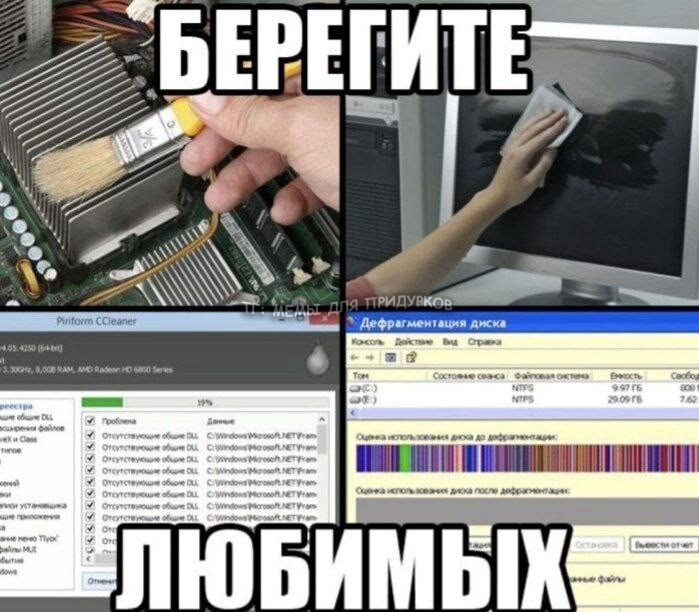

# Консультация к зачёту для группы Буйловой М.А., Блок №2 ✌

## 1. Алгоритм Косарайю. Обоснование корректности полученного результата

### Поиск компонент сильной связности (SCC)
**Определение**: Две вершины ориентированного графа связаны сильно (англ. strongly connected), если существует путь из одной в другую и наоборот. Иными словами, они обе лежат в каком-то цикле.

Компоненты сильной связности (SCC) — это максимальные подмножества вершин ориентированного графа, в которых каждая вершина достижима из каждой (есть путь в обе стороны)

Понятно, что такое отношение транзитивно: если a и b сильно связны, и b и c сильно связны, то a и c тоже сильно связны. Поэтому все вершины распадаются на компоненты сильной связности — такое разбиение вершин, что внутри одной компоненты все вершины сильно связаны, а между вершинами разных компонент сильной связности нет.

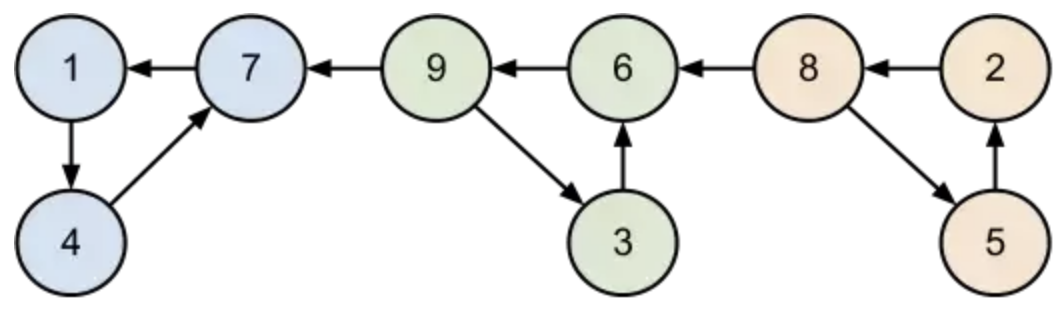

Часто рассматривают граф, составленный из самих компонент сильной связности, а не индивидуальных вершин. Очевидно, такой граф уже будет ациклическим, и с ним проще работать. **Задачу о сжатии каждой компоненты сильной связности в одну вершину называют конденсацией графа**.



### Алгоритм Косарайю

Алгоритм Косарайю находит компоненты сильной связности в ориентированном графе за $O(V+E)$ с помощью **двух DFS**: один на исходном графе, второй на транспонированном.

Алгоритм:
1. Выполнение поиска в глубину (DFS) на исходном графе:
* Сначала мы проводим DFS на исходном графе и записываем время завершения узлов (то есть время, когда DFS полностью исследует узел).

2. Выполнение DFS на транспонированном графе:
* Затем мы меняем направление всех рёбер графа, чтобы создать транспозиционированный граф.
* Далее мы проводим DFS на транспонированном графе, рассматривая узлы в убывающем порядке их финишных времен, зафиксированных на первой фазе.
* Каждое прохождение DFS в этой фазе даст нам один SCC.

In [ ]:
def kosaraju(graph):
    n = len(graph)

    # 1. DFS на исходном графе → порядок завершения
    visited = [False] * n
    order = []

    def dfs1(u):
        visited[u] = True
        for v in graph[u]:
            if not visited[v]:
                dfs1(v)
        order.append(u)  # Добавляем ПОСЛЕ обработки соседей

    for i in range(n):
        if not visited[i]:
            dfs1(i)

    order.reverse()  # Порядок ФИНИШНОГО времени

    # 2. Транспонированный граф
    transpose = [[] for _ in range(n)]
    for u in range(n):
        for v in graph[u]:
            transpose[v].append(u)
    print(f'transpose: {transpose}')

    # 3. DFS на транспонированном в порядке order
    visited = [False] * n
    scc = []

    def dfs2(u, component):
        visited[u] = True
        component.append(u)
        for v in transpose[u]:
            if not visited[v]:
                dfs2(v, component)

    for u in order:
        if not visited[u]:
            component = []
            dfs2(u, component)
            scc.append(component)

    return scc

# Тест
graph1 = [[1,2], [3], [1], [], [2, 1]]
print(kosaraju(graph1))
graph2 = [[3], [7], [5], [6], [1], [8], [0], [5, 4], [6, 2]]
print(kosaraju(graph2))
graph3 = [[1], [2], [0, 3], [4], [5, 7], [6], [0, 2, 5], [3, 5, 8], [4, 7]]
print(kosaraju(graph3))



transpose: [[], [0, 2, 4], [0, 4], [1], []]
[[4], [0], [2], [1], [3]]
transpose: [[6], [4], [8], [0], [7], [2, 7], [3, 8], [1], [5]]
[[1, 4, 7], [5, 2, 8], [0, 6, 3]]
transpose: [[2, 6], [0], [1, 6], [2, 7], [3, 8], [4, 6, 7], [5], [4, 8], [7]]
[[0, 2, 1, 6, 5, 4, 3, 7, 8]]


Первый DFS даёт порядок завершения (finish times), который ранжирует вершины по "глубине" достижимости. Второй DFS на транспонированном графе группирует вершины в SCC по этому рангу.

* Почему нужен транспонированный граф

В исходном графе:

из компоненты можно «утечь» в другие

В транспонированном:

рёбра разворачиваются
и теперь:
из компоненты нельзя попасть в «следующие» по DAG
Это изолирует компоненту при DFS.

* Второй DFS

Берём вершину с максимальным временем выхода и запускаем DFS в Gᵗ.

Что происходит:

Мы начинаем с «источника» DAG (в транспонированном графе)
DFS не может выйти за пределы SCC - значит, обойдём ровно одну компоненту

Алгоритм корректен, потому что:

1. Конденсация графа даёт ациклический граф
2. Порядок выхода DFS задаёт топологический порядок компонент
3. Транспонирование инвертирует рёбра
4. DFS во втором проходе не выходит за пределы компоненты связности
5. Каждая компонента извлекается ровно один раз

**Сложность**  
Время: $O(V + E)$  
Память: $O(V + E)$

## 2. Алгоритм Форда-Беллмана. Асимптотика алгоритма, проверка графа на наличие отрицательного цикла.

Алгоритм Беллмана-Форда находит кратчайшие пути от одной вершины до всех остальных и работает с отрицательными весами (в отличие от Дейкстры).

**Алгоритм**:
1. Инициализация расстояний до всех вершин как бесконечные, а расстояние до исходной вершины — как 0.

2. Релаксация всех рёбер |V| - 1 раз.

3. Если мы можем найти более короткий путь, то в графе возникает отрицательный весовой цикл.

Релаксация:
```python
for _ in range(V-1):
    for каждое ребро (u,v,w):
        if dist[v] > dist[u] + w:
            dist[v] = dist[u] + w
```


In [ ]:
def bellman_ford(graph, source):
    # Step 1: Initialize distances
    distances = {vertex: float('inf') for vertex in graph}
    distances[source] = 0

    # Step 2: Relax edges |V| - 1 times
    for _ in range(len(graph) - 1):
        for u in graph:
            for v, weight in graph[u].items():
                if distances[u] != float('inf') and distances[u] + weight < distances[v]:
                    distances[v] = distances[u] + weight

    # Step 3: Check for negative weight cycles
    for u in graph:
        for v, weight in graph[u].items():
            if distances[u] != float('inf') and distances[u] + weight < distances[v]:
                raise ValueError("Graph contains negative weight cycle")

    return distances


# Example
graph = {
    'A': {'B': -1, 'C': 4},
    'B': {'C': 3, 'D': 2, 'E': 2, 'A': -3},
    'C': {'B': -4},
    'D': {'B': 1, 'C': 5},
    'E': {'D': -3}
}
source = 'A'

shortest_distances = bellman_ford(graph, source)
print(shortest_distances)

ValueError: Graph contains negative weight cycle

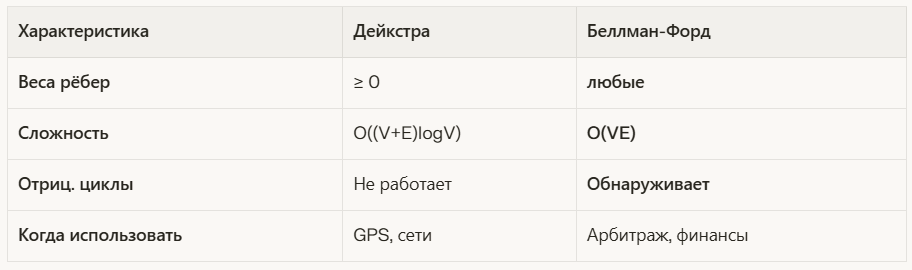

## 3. Алгоритм Флойда-Уоршелла. Асимптотика алгоритма, проверка графа на наличие отрицательного цикла

Алгоритм Флойда-Уоршелла находит кратчайшие пути между **всеми** парами вершин за $O(V^3)$.

**Задача**: Во взвешенном графе найти длины кратчайших путей между **всевозможными** парами вершин   
**Ограничения**: Недопустимы циклы отрицательной длины. Цикл отрицательной длины — это замкнутый путь в графе, сумма весов рёбер которого отрицательна.

**Идея**: Возвращаемся к динамическому программированию: постепенно разрешаем пути через больше промежуточных вершин.
```python
dp[k][i][j] = кратчайший путь от i до j ИСПОЛЬЗУЯ ТОЛЬКО вершины 0..k
```
```python
dist[i][j] = min(
  dist[i][j],              # прямой путь
  dist[i][k] + dist[k][j]  # через промежуточную k
)
```
Для каждой k проверяем: "А не лучше ли идти через k?"

На картинках синими кружочками отметила пары, а оранжевыми результат.

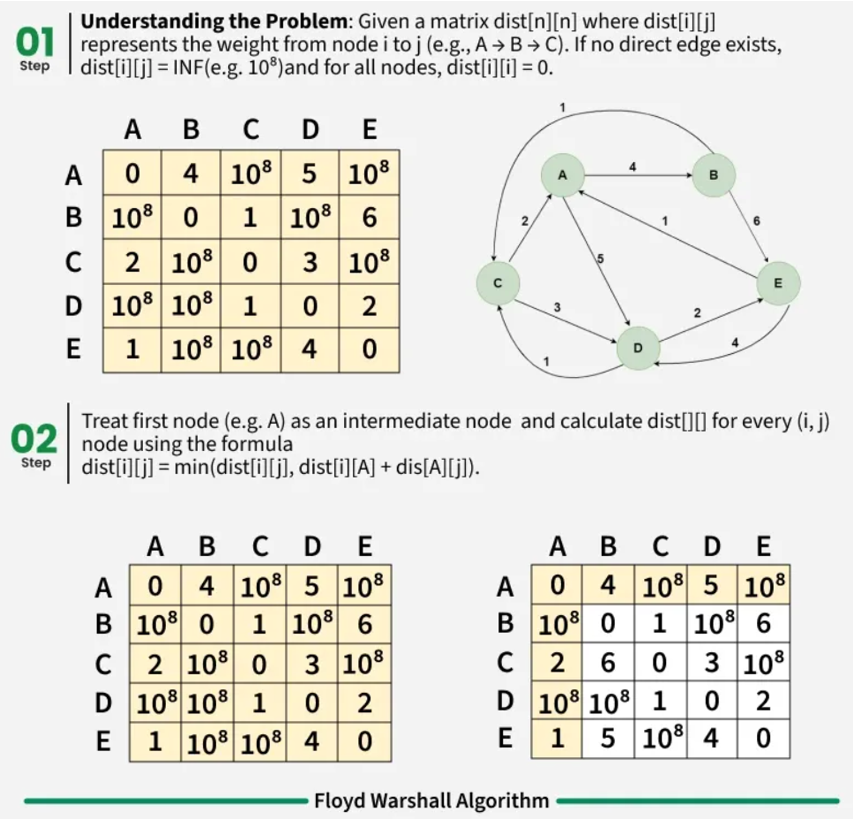

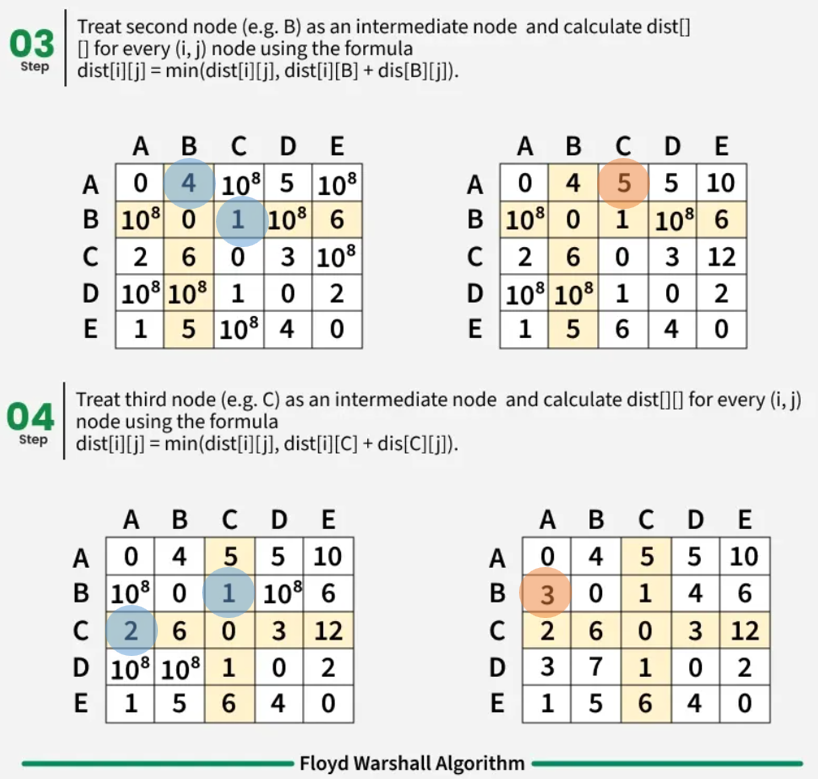

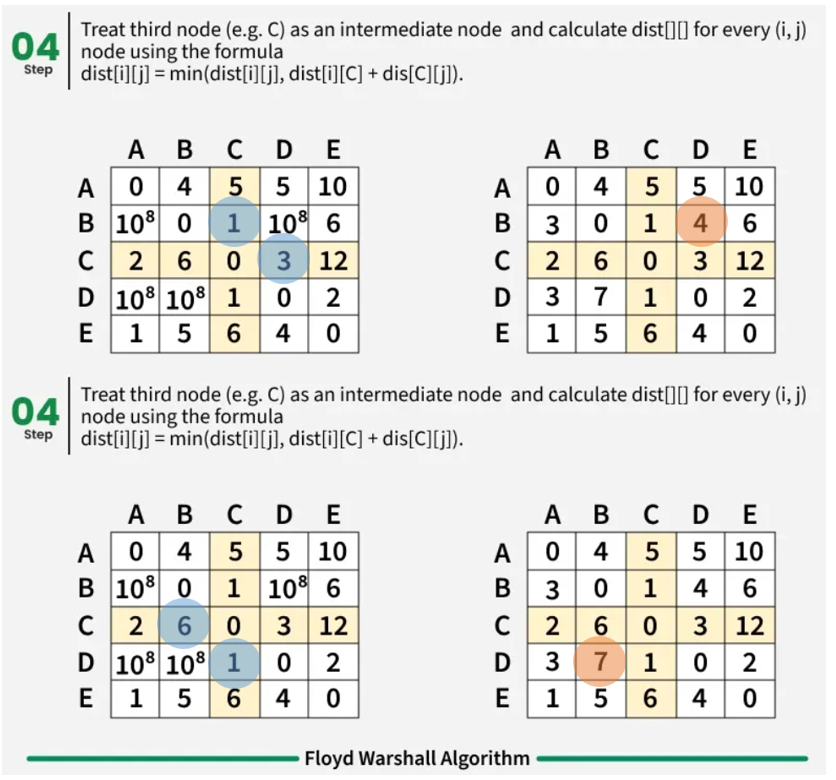

In [ ]:
def floyd_warshall(graph):
    n = len(graph)
    dist = [row[:] for row in graph]  # копия матрицы

    # Для каждой промежуточной вершины k
    for k in range(n):
        print(f"Через вершину {k}:")
        for i in range(n):
            for j in range(n):
                # Путь через k лучше прямого?
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
                    print(f"  {i}→{j}: {dist[i][j]} через {k}")

    return dist

INF = float('inf')
graph = [
    [0, 4, INF, 5, INF],
    [INF, 0, 1, INF, 6],
    [2, INF, 0, 3, INF],
    [INF, INF, 1, 0, 2],
    [1, INF, INF, 4, 0]
]

result = floyd_warshall(graph)
print("Финальные расстояния:")
for i in range(len(result)):
    print(f"{i}: {result[i]}")


Начальная матрица:
[0, 4, inf, 5, inf]
[inf, 0, 1, inf, 6]
[2, inf, 0, 3, inf]
[inf, inf, 1, 0, 2]
[1, inf, inf, 4, 0]
Через вершину 0:
  2→1: 6 через 0
  4→1: 5 через 0
Через вершину 1:
  0→2: 5 через 1
  0→4: 10 через 1
  2→4: 12 через 1
  4→2: 6 через 1
Через вершину 2:
  1→0: 3 через 2
  1→3: 4 через 2
  3→0: 3 через 2
  3→1: 7 через 2
Через вершину 3:
  0→4: 7 через 3
  2→4: 5 через 3
  4→2: 5 через 3
Через вершину 4:
Финальные расстояния:
0: [0, 4, 5, 5, 7]
1: [3, 0, 1, 4, 6]
2: [2, 6, 0, 3, 5]
3: [3, 7, 1, 0, 2]
4: [1, 5, 5, 4, 0]


Время: $O(V^3)$  
Память: $O(V^2)$

## 4. Минимальное остовное дерево, алгоритмы Борувки, Прима, Краскала (на выбор 2 из 3). Асимптотика работы.

См. первую часть консультации, билет №5.

## 5. Система непересекающихся множеств. Эвристика ранга, эвристика сжатия пути.

**DSU (Disjoint Set Union)** — структура данных, которая поддерживает разбиение множества элементов на непересекающиеся подмножества.

Она обеспечивает три основные операции:

* **make_set(v)** — создать множество из одного элемента
* **find(v)** — найти представителя (корень) множества
* **union(a, b)** — объединить множества

Каждое множество представляется в виде дерева:
* у каждого элемента есть родитель
* корень — представитель множества

Проблема: Без оптимизаций дерево может выродиться в цепочку:
```python
1 ← 2 ← 3 ← 4 ← 5
```
тогда find работает за $O(n)$



### Эвристика ранга (Union by Rank)
Идея:
При объединении двух деревьев подвешиваем меньшее по высоте дерево к большему

Как хранится:  
у каждого корня есть **rank** (ранг) — приближённая высота дерева  
Правило:
* если $rank[a] < rank[b]$ → $a$ к $b$
* если $rank[a] > rank[b]$ → $b$ к $a$
* если равны → любой к другому + увеличиваем ранг

Почему это работает
* высота дерева растёт очень медленно
* гарантируется почти логарифмическая глубина

### Эвристика сжатия пути (Path Compression)
Идея:

* При вызове **find(v)**:
все вершины на пути подвешиваются сразу к корню

Пример:

До:
```python
1 ← 2 ← 3 ← 4
```
После find(4):
```python
1
↑ ↑ ↑
2 3 4
```

Почему это эффективно:
* повторные find становятся почти мгновенными
* структура «выпрямляется»

### **Корректность**
1. Представитель корректен
каждый элемент указывает на корень
корень однозначно определяет множество
2. Union не нарушает разбиение
объединяются только корни
множества остаются непересекающимися
3. Path compression не ломает структуру
просто меняет родителей
но все элементы всё равно ведут к тому же корню

* Ранг — чтобы не росло вверх
* Сжатие пути — чтобы сплющивалось вниз
* Вместе → почти O(1)

## 6. Паросочетания. Алгоритм Куна поиска максимального паросочетания.

Задача. Пусть есть $n$ мальчиков и $m$ девочек. Про каждого мальчика и про каждую девочку известно, с кем они не против танцевать. Нужно составить как можно больше пар, в которых партнёры хотят танцевать друг с другом.

Формализуем эту задачу, представив мальчиков и девочек как вершины в двудольном графе, рёбрами которого будет отношение «могут танцевать вместе». Будем в дальнейшем обозначать левую долю графа как
$L$, а правую долю как $R$.

**Паросочетанием** $M$ называется набор попарно несмежных рёбер графа (иными словами, любой вершине графа должно быть инцидентно не более одного ребра из $M$).

Все вершины, у которых есть смежное ребро из паросочетания (т.е. которые имеют степень ровно один в подграфе, образованном $M$), назовём насыщенными этим паросочетанием.

**Мощностью паросочетания** назовём количество рёбер в нём. Наибольшим (максимальным) паросочетанием назовём паросочетание, мощность которого максимальна среди всех возможных паросочетаний в данном графе, а совершенным — где все вершины левой доли им насыщенны.

Паросочетания можно искать не только в двудольных графах, однако общий алгоритм неприятно кодить, и он работает за $O(n^3)$, так что в этой главе мы сфокусируемся только на двудольных графах.



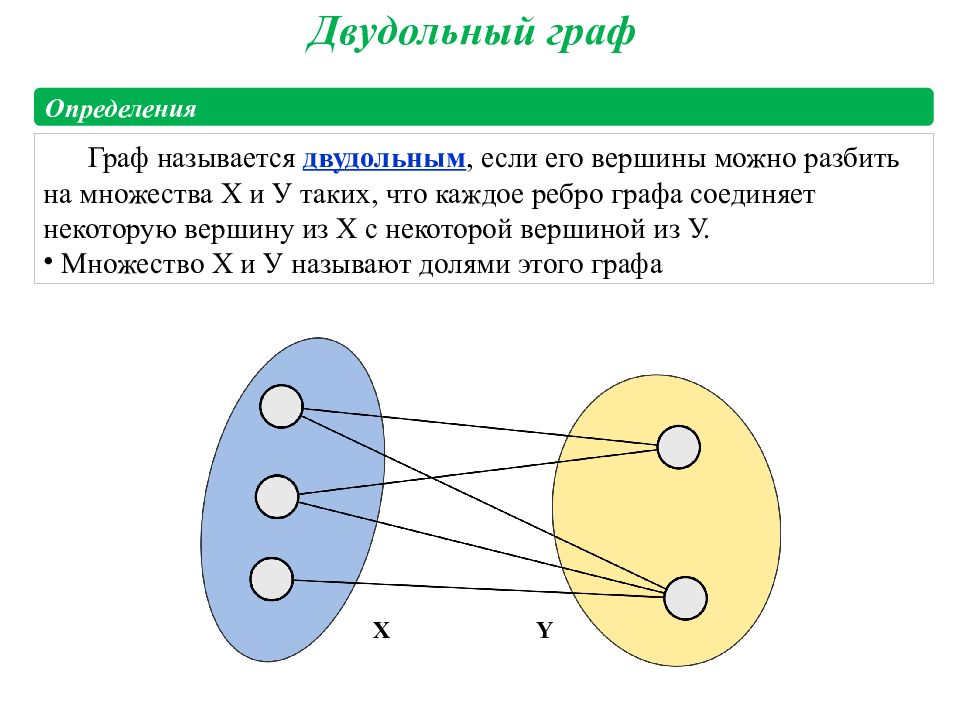

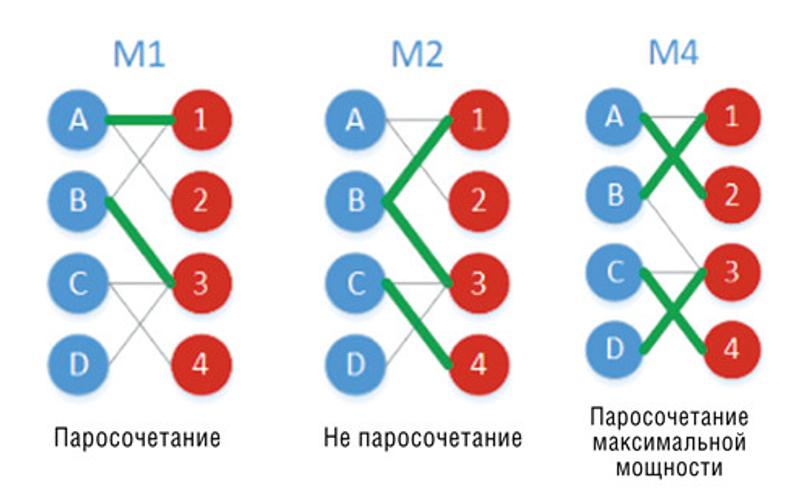

Введём ещё несколько понятий:
**Цепью длины k** назовём некоторый простой путь (т.е. не содержащий повторяющихся вершин или рёбер), содержащий ровно **k** рёбер.

**Чередующейся цепью** относительно некоторого паросочетания назовём простой путь длины **k** в котором рёбра поочередно принадлежат/не принадлежат паросочетанию.

**Увеличивающей цепью** относительно некоторого паросочетания назовём чередующуюся цепь, у которой начальная и конечная вершины не принадлежат паросочетанию.

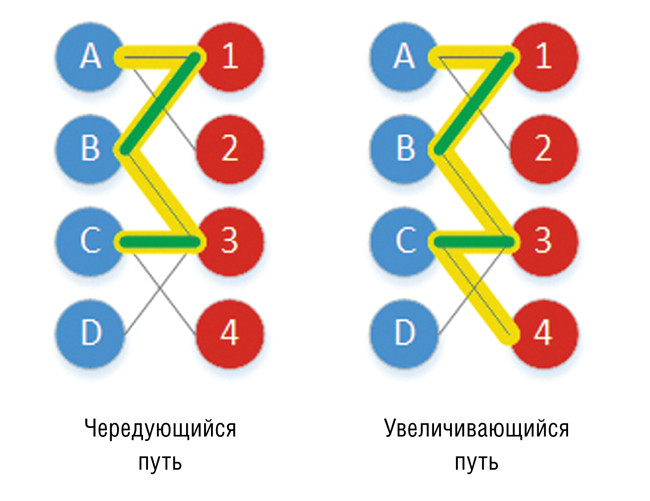

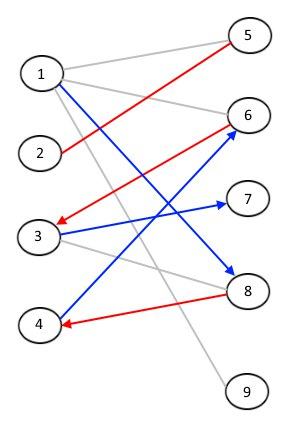

Здесь красными помечены вершины паросочетания, а в графе есть увеличивающая цепь: 1→8→4→6→3→7

Как подсказывает название, с помощью увеличивающей цепи можно увеличить мощность паросочетания на единицу. Для этого можно взять такую цепь и провести чередование: убрать из паросочетания все рёбра, принадлежащие цепи, и вместо них добавить все остальные ребра цепи.

Всего в увеличивающей цепи нечетное число рёбер, а первое и последнее были не в паросочетании. После чередования каждая затронутая вершина будет соединена ровно с одной из другой доли. Значит, после чередования паросочетание осталось корректным, а его мощность увеличилась ровно на единицу.

В примере выше добавятся синие рёбра (1,8), (3,7) и
 (4,6), а удалятся красные (3,6) и (4,8). С ребром
(2,5) ничего не случится — оно не в увеличивающей цепи. Таким образом, размер паросочетания увеличится на единицу.

Раз чередованием увеличивающей цепи можно увеличить мощность паросочетания на единицу, то у максимального паросочетания увеличивающих цепей быть не должно. Оказывается, обратное тоже верно.

### Теорема Бержа
**Теорема.** Паросочетание без увеличивающих цепей является максимальным.

**Доказательство** проведём от противного: пусть есть два паросочетания вершин $∣A∣≤∣B∣$, и для $A$ нет увеличивающих путей. Покажем, как найти этот путь и увеличить $A$ на единицу.

Раскрасим ребра из паросочетания, соответствующего
$A$ в красный цвет, $B$ — в синий, а ребра из обоих паросочетаний — в пурпурный. Рассмотрим теперь граф из только красных и синих ребер. Так как это фактически симметричная разность двух паросочетаний, у каждой вершины будет не более 2 смежных ребер. Значит, любая компонента связности в нём представляет собой либо путь, либо цикл, состоящий из чередующихся красных и синих ребер. В любом цикле будет равное число красных и синих рёбер, а так как всего синих рёбер больше, то должен существовать путь, начинающийся и оканчивающийся синим ребром — он и будет увеличивающей цепью для $A$, а значит
$A$ не максимальное, и мы получили противоречие.


### Алгоритм Куна
**Лемма Бержа** говорит о том, что паросочетание без увеличивающих цепей является максимальным.

Её важное следствие состоит в том, что максимальное паросочетание можно строить инкрементально, на каждом шаге делая поиск увеличивающей цепи и проводя её чередование.

**Алгоритм Куна** ровно в этом и заключается — начнем с пустого паросочетания и будем искать увеличивающие цепи, пока они ищутся.

Для поиска увеличивающей цепи можно мысленно построить граф, в котором из правой доли в левую можно идти только по рёбрам паросочетания, а из левой в правую — по любым. Тогда можно запустить поиск любого пути из свободной вершины левой доли в какую-нибудь свободную вершину правой доли в измененном графе, и ровно такой путь и будет увеличивающим.

In [1]:
def kuhn_matching(graph):
    """Алгоритм Куна для двудольного графа
    graph[u] = список соседей v из правой доли
    """
    n = len(graph)  # левая доля
    pairU = [-1] * n  # пара для U (левая)
    pairV = [-1] * 1000  # пара для V (правая, max размер)

    def dfs(u, visited):
        """Ищет увеличивающую цепь из u"""
        for v in graph[u]:
            if not visited[v]:
                visited[v] = True
                # v свободна ИЛИ можем переставить pairV[v]
                if pairV[v] == -1 or dfs(pairV[v], visited):
                    pairU[u] = v
                    pairV[v] = u
                    return True
        return False

    matching = 0
    for u in range(n):
        if pairU[u] == -1:  # свободная вершина U
            visited = [False] * 1000
            if dfs(u, visited):
                matching += 1

    return matching, pairU

graph = [
    [0,1],  # A → W,X
    [1],    # B → X
    [2]     # C → Y
]

size, pairs = kuhn_matching(graph)
print(f"Размер паросочетания: {size}")
print("Пары L→R:", pairs)


Размер паросочетания: 3
Пары L→R: [0, 1, 2]


Алгоритм ровно $n$ раз ищет увеличивающий путь, каждый раз просматривая не более $m$ рёбер, а значит суммарно отработает за $O(nm)$.

## 7. Алгоритм Форда-Фалкерсона поиска максимального потока в сети. Асимптотика работы

Ещё одно определение:  
**Дополнительный поток** (чаще говорят увеличивающий поток или augmenting flow) — это количество потока, которое можно дополнительно пропустить по найденному увеличивающему пути в остаточной сети.

Это сколько ещё потока можно “добавить” по выбранному пути от источника к стоку.

**Алгоритм Форда–Фалкерсона** — классический метод решения задачи максимального потока в сети. Он был предложен математиками Лестером Рэндольфом Фордом-младшим и Делбертом Рэем Фалкерсоном в 1956 году.

**Главная идея алгоритма**:

Пока существует путь из источника $s$ в сток $t$, по которому можно пропустить дополнительный поток — увеличиваем поток вдоль этого пути.

Представьте систему труб:

* каждая труба имеет максимальную пропускную способность

* вода идёт от источника к стоку

Мы пытаемся протолкнуть как можно больше воды.

Алгоритм делает это постепенно:

* находит путь

* отправляет по нему максимально возможный поток

* обновляет сеть

* повторяет

Ключевая идея алгоритма — **остаточная сеть**.

Для каждого ребра создаются:

* прямое ребро

* обратное ребро

Если по ребру уже течёт поток, его можно частично отменить, используя обратное ребро.

**Остаточная пропускная способность**

$c_f(u,v)=c(u,v)−f(u,v)$

сколько ещё можно пропустить через ребро.

In [ ]:
from collections import defaultdict

def dfs(graph, s, t, visited, flow):
    if s == t:
        return flow

    visited.add(s)

    for v in graph[s]:
        capacity = graph[s][v]
        if v not in visited and capacity > 0:
            pushed = dfs(graph, v, t, visited, min(flow, capacity))
            if pushed > 0:
                graph[s][v] -= pushed
                graph[v][s] += pushed
                return pushed

    return 0


def ford_fulkerson(graph, source, sink):
    max_flow = 0

    while True:
        visited = set()
        pushed = dfs(graph, source, sink, visited, float('inf'))

        if pushed == 0:
            break

        max_flow += pushed

    return max_flow

Посмотрим на ключевой участок:
```python
graph[s][v] -= pushed
graph[v][s] += pushed
```
Здесь:
```python
graph[s][v] — уменьшаем остаточную пропускную способность

graph[v][s] — увеличиваем пропускную способность обратного ребра
```
Если обратного ребра раньше не было, defaultdict создаёт его автоматически:
```python
graph[v][s] = 0
```
и затем увеличивает.

### Более полная реализация
```
graph[u][v] = остаточная пропускная способность
```

In [ ]:
from collections import defaultdict

class Graph:
    def __init__(self):
        # остаточный граф
        self.graph = defaultdict(lambda: defaultdict(int))

    def add_edge(self, u, v, capacity):
        # добавляем прямое ребро
        self.graph[u][v] += capacity

        # создаём обратное ребро (если его ещё нет)
        self.graph[v][u] += 0

    def dfs(self, u, t, visited, flow):
        # если дошли до стока — возвращаем поток
        if u == t:
            return flow

        visited.add(u)

        # перебираем соседей
        for v in self.graph[u]:
            capacity = self.graph[u][v]

            # если не посещали и есть остаточная пропускная способность
            if v not in visited and capacity > 0:

                pushed = self.dfs(v, t, visited, min(flow, capacity))

                if pushed > 0:
                    # уменьшаем прямое ребро
                    self.graph[u][v] -= pushed

                    # увеличиваем обратное
                    self.graph[v][u] += pushed

                    return pushed

        return 0

    def ford_fulkerson(self, s, t):
        max_flow = 0

        while True:
            visited = set()

            pushed = self.dfs(s, t, visited, float('inf'))

            if pushed == 0:
                break

            max_flow += pushed

        return max_flow

In [ ]:
g = Graph()

g.add_edge(0, 1, 10)
g.add_edge(0, 2, 5)
g.add_edge(1, 2, 15)
g.add_edge(1, 3, 10)
g.add_edge(2, 3, 10)

print(g.ford_fulkerson(0, 3))

15


Разберём пример, где алгоритм сначала выбирает неудачный путь, а потом исправляет его с помощью обратных рёбер.

```
s → A (10)
s → B (10)
A → B (2)
A → t (8)
B → t (10)
```
Допустим DFS нашёл путь:
```
s → A → B → t
```
Пропускные способности:
```
s → A = 10
A → B = 2
B → t = 10
```
Минимум:
```
min(10,2,10) = 2
```
Добавляем поток 2.

Поток после шага
```
s → A : 2
A → B : 2
B → t : 2
```
Остаточные capacity:
```
s → A : 8
A → B : 0
B → t : 8
```
И появляются обратные рёбра:
```
A ← B : 2
A ← s : 2
t ← B : 2
```

Теперь алгоритм найдёт путь:
```
s → A → t
```
Пропускные способности:
```
s → A = 8
A → t = 8
```
Минимум:
```
8
```
Добавляем поток 8.

Поток теперь
```
s → A = 10
A → B = 2
A → t = 8
B → t = 2
```

Третий путь

Следующий путь:
```
s → B → t
```
Минимум:
```
10
```
Но B → t уже содержит поток 2, поэтому остаточная capacity:
```
B → t = 8
```
Добавляем 8.

Итоговый поток
```
s → A = 10
s → B = 8
A → B = 2
A → t = 8
B → t = 10
```
Общий поток:
```
18
```

### Сложность

Зависит от того, как ищется путь.

В общем виде: $O(E⋅∣f∣)$

где:
$E$ — число рёбер  
$∣f∣$ — значение максимального потока

## 8. Алгоритм Эдмондса-Карпа. Асимптотика работы.

Это улучшенная версия Алгоритма Форда–Фалкерсона.
Он был предложен учёными Джеком Эдмондсом и Ричардом Карпом.

**Главное отличие:**

увеличивающий путь ищется по кратчайшему числу рёбер с помощью BFS.


**Идея:**

1️⃣ строим остаточную сеть  
2️⃣ ищем кратчайший путь (по числу рёбер) из $s$ в $t$  
3️⃣ увеличиваем поток на этом пути  
4️⃣ обновляем остаточную сеть  
5️⃣ повторяем

Итак,

1️⃣ Инициализация

Все потоки равны: $f(u,v)=0$

2️⃣ Построение остаточной сети

Для каждого ребра:
$c_f (u,v)=c(u,v)−f(u,v)$

3️⃣ Поиск увеличивающего пути

Используем BFS, чтобы найти путь: $s→t$,

где $c_f (u,v)>0$

4️⃣ Определение дополнительного потока:
$Δ = min (c_f(u,v))$

минимальная пропускная способность на пути.

5️⃣ Обновление потоков

Для каждого ребра пути:

* увеличиваем прямое ребро

* уменьшаем обратное

6️⃣ Повтор

Алгоритм работает, пока существует путь $s→t$.

**Сложность**

Алгоритм Эдмондса–Карпа имеет гарантированную сложность:
$O(VE^2)$
где:
$V$ — число вершин
$E$ — число рёбер

**Причина**:

* каждый BFS стоит $O(E)$

* число увеличивающих путей $≤ O(VE)$

In [1]:
from collections import deque

def bfs(graph, s, t, parent):
    visited = set()
    queue = deque([s])
    visited.add(s)

    while queue:
        u = queue.popleft()

        for v in graph[u]:
            if v not in visited and graph[u][v] > 0:
                parent[v] = u
                visited.add(v)

                if v == t:
                    return True

                queue.append(v)

    return False


def edmonds_karp(graph, s, t):
    parent = {}
    max_flow = 0

    while bfs(graph, s, t, parent):

        flow = float('inf')
        v = t

        while v != s:
            u = parent[v]
            flow = min(flow, graph[u][v])
            v = u

        v = t
        while v != s:
            u = parent[v]

            graph[u][v] -= flow
            graph[v][u] += flow

            v = u

        max_flow += flow

    return max_flow

In [2]:
from collections import defaultdict, deque

# создание графа
graph = defaultdict(lambda: defaultdict(int))

# добавление рёбер
graph['s']['A'] = 10
graph['s']['B'] = 5
graph['A']['B'] = 15
graph['A']['t'] = 10
graph['B']['t'] = 10

# обязательно создаём обратные рёбра
for u in list(graph):
    for v in list(graph[u]):
        if u not in graph[v]:
            graph[v][u] = 0

In [3]:
max_flow = edmonds_karp(graph, 's', 't')
print("Max flow:", max_flow)

Max flow: 15


## 9. Алгоритм Диница. Асимптотика работы.

### **Необходимые определения**
Введём три необходимых определения (каждое из них является независимым от остальных), которые затем будут использоваться в алгоритме Диница.

**Остаточной сетью** $G^R$ по отношению к сети $G$ и некоторому потоку f в ней называется сеть, в которой каждому ребру $(u,v) \in G$ с пропускной способностью $c_{uv}$ и потоком $f_{uv}$ соответствуют два ребра:

* $(u,v)$ с пропускной способностью $c_{uv}^R = c_{uv} - f_{uv}$
* $(v,u)$ с пропускной способностью $c_{vu}^R = f_{uv}$  

Стоит отметить, что при таком определении в остаточной сети могут появляться кратные рёбра: если в исходной сети было как ребро $(u,v)$, так и $(v,u)$.

Остаточное ребро можно интуитивно понимать как меру того, насколько ещё можно увеличить поток вдоль какого-то ребра. В самом деле, если по ребру $(u,v)$ с пропускной способностью $c_{uv}$ протекает поток $f_{uv}$, то потенциально по нему можно пропустить ещё $c_{uv}-f_{uv}$ единиц потока, а в обратную сторону можно пропустить до $f_{uv}$ единиц потока, что будет означать отмену потока в первоначальном направлении.

**Блокирующим потоком** в данной сети называется такой поток, что любой путь из истока $s$ в сток $t$ содержит **насыщенное** этим потоком ребро. Иными словами, в данной сети не найдётся такого пути из истока в сток, вдоль которого можно беспрепятственно увеличить поток.

Блокирующий поток не обязательно максимален. Теорема Форда-Фалкерсона говорит о том, что поток будет максимальным тогда и только тогда, когда в остаточной сети не найдётся $s$ -> $t$ пути; в блокирующем же потоке ничего не утверждается о существовании пути по рёбрам, появляющимся в остаточной сети.

**Слоистая сеть** для данной сети строится следующим образом. Сначала определяются длины кратчайших путей из истока $s$ до всех остальных вершин; назовём уровнем ${\rm level}[v]$ вершины её расстояние от истока. Тогда в слоистую сеть включают все те рёбра $(u,v)$ исходной сети, которые ведут с одного уровня на какой-либо другой, более поздний, уровень, т.е. ${\rm level}[u] + 1 = {\rm level}[v]$ (почему в этом случае разница расстояний не может превосходить единицы, следует из свойства кратчайших расстояний). Таким образом, удаляются все рёбра, расположенные целиком внутри уровней, а также рёбра, ведущие назад, к предыдущим уровням.

Очевидно, слоистая сеть ациклична. Кроме того, любой s-t путь в слоистой сети является кратчайшим путём в исходной сети.

Построить слоистую сеть по данной сети очень легко: для этого надо запустить обход в ширину по рёбрам этой сети, посчитав тем самым для каждой вершины величину ${\rm level}[]$, и затем внести в слоистую сеть все подходящие рёбра.

**Примечание**. Термин "слоистая сеть" в русскоязычной литературе не употребляется; обычно эта конструкция называется просто "вспомогательным графом". Впрочем, на английском языке обычно используется термин "layered network".

### Схема алгоритма
Алгоритм представляет собой несколько фаз. На каждой фазе сначала строится остаточная сеть, затем по отношению к ней строится слоистая сеть (обходом в ширину), а в ней ищется произвольный блокирующий поток. Найденный блокирующий поток прибавляется к текущему потоку, и на этом очередная итерация заканчивается.

Этот алгоритм схож с алгоритмом Эдмондса-Карпа, но основное отличие можно понимать так: на каждой итерации поток увеличивается не вдоль одного кратчайшего $s$ -> $t$ пути, а вдоль целого набора таких путей (ведь именно такими путями и являются пути в блокирующем потоке слоистой сети).

### Поиск блокирующего потока
Чтобы завершить построение алгоритма Диница, надо описать алгоритм нахождения блокирующего потока в слоистой сети — ключевое место алгоритма.

Мы рассмотрим три возможных варианта реализации поиска блокирующего потока:

1. Искать $s$ -> $t$ пути по одному, пока такие пути находятся.

Путь можно найти за $O(m)$ обходом в глубину, а всего таких путей будет $O(m)$ (поскольку каждый путь насыщает как минимум одно ребро). Итоговая асимптотика поиска одного блокирующего потока составит $O(m^2)$.

2. Аналогично предыдущей идее, однако удалять в процессе обхода в глубину из графа все "лишние" рёбра, т.е. рёбра, вдоль которых не получится дойти до стока.

Это очень легко реализовать: достаточно удалять ребро после того, как мы просмотрели его в обходе в глубину (кроме того случая, когда мы прошли вдоль ребра и нашли путь до стока). С точки зрения реализации, надо просто поддерживать в списке смежности каждой вершины указатель на первое неудалённое ребро, и увеличивать этот указать в цикле внутри обхода в глубину.

Оценим асимптотику этого решения. Каждый обход в глубину завершается либо насыщением как минимум одного ребра (если этот обход достиг стока), либо продвижением вперёд как минимум одного указателя (в противном случае). Можно понять, что один запуск обхода в глубину из основной программы работает за $O (k + n)$, где $k$ — число продвижений указателей. Учитывая, что всего запусков обхода в глубину в рамках поиска одного блокирующего потока будет $O (p)$, где $p$ — число рёбер, насыщенных этим блокирующим потоком, то весь алгоритм поиска блокирующего потока отработает за $O (p k + p n)$, что, учитывая, что все указатели в сумме прошли расстояние $O (m)$, даёт асимптотику $O (m + pn)$. В худшем случае, когда блокирующий поток насыщает все рёбра, асимптотика получается $O (n m)$; эта асимптотика и будет использоваться далее.

Этот способ решения является по-прежнему простым для реализации, но достаточно эффективным, и потому наиболее часто применяется на практике.

### Асимптотика

Таким образом, весь алгоритм Диница выполняется за $O (n^2 m)$, если блокирующий поток искать описанным выше способом за $O (n m)$.

Временная сложность реализации Эдмонда-Карпа равна $O(VE^2)$. Алгоритм Диница - $O(EV^2)$.

Как и алгоритм Эдмонда-Карпа, алгоритм Диница использует следующие концепции:

* Поток является максимальным, если в остаточном графе нет пути от s к t.
* BFS используется в цикле. Однако есть разница в том, как мы используем BFS в обоих алгоритмах.
В алгоритме Эдмонда-Карпа мы используем BFS, чтобы найти дополнительный путь и отправить поток по этому пути. В алгоритме Диница мы используем BFS, чтобы проверить, возможен ли дополнительный поток, и построить граф уровней. В графе уровней мы назначаем уровни всем узлам, уровень узла — это наименьшее расстояние (по количеству рёбер) от узла от источника. После построения графа уровней мы отправляем несколько потоков с помощью этого графа уровней. Вот почему он работает лучше, чем Эдмонд-Карп.

Дальше есть иллюстрации, советую проделать руками на бумажке!

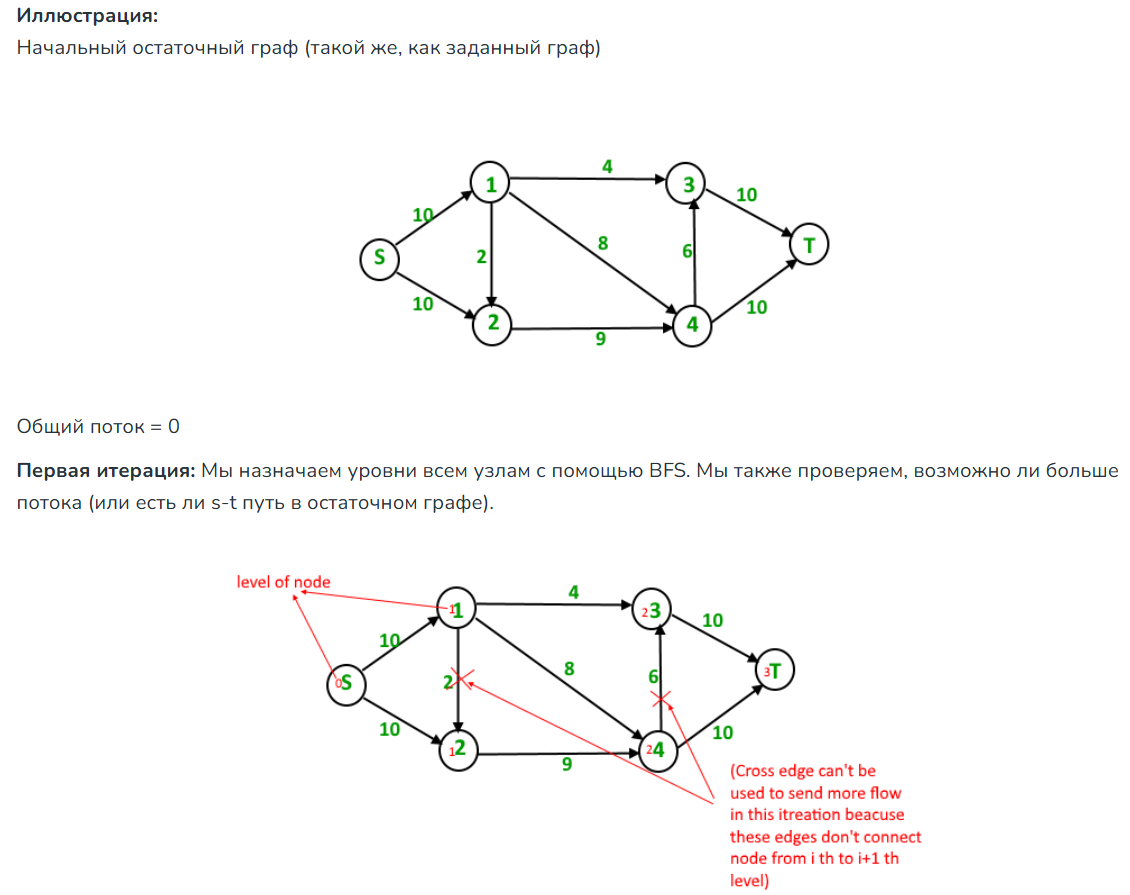

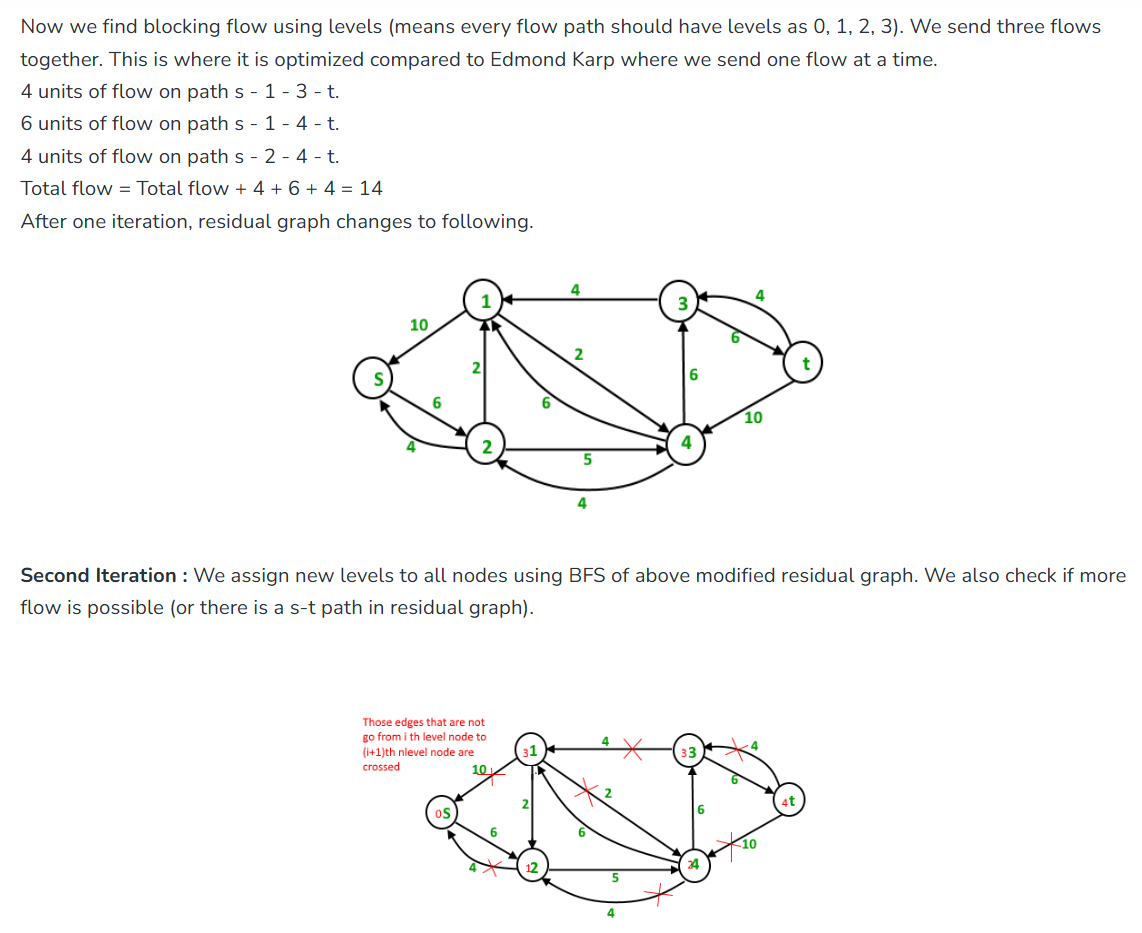

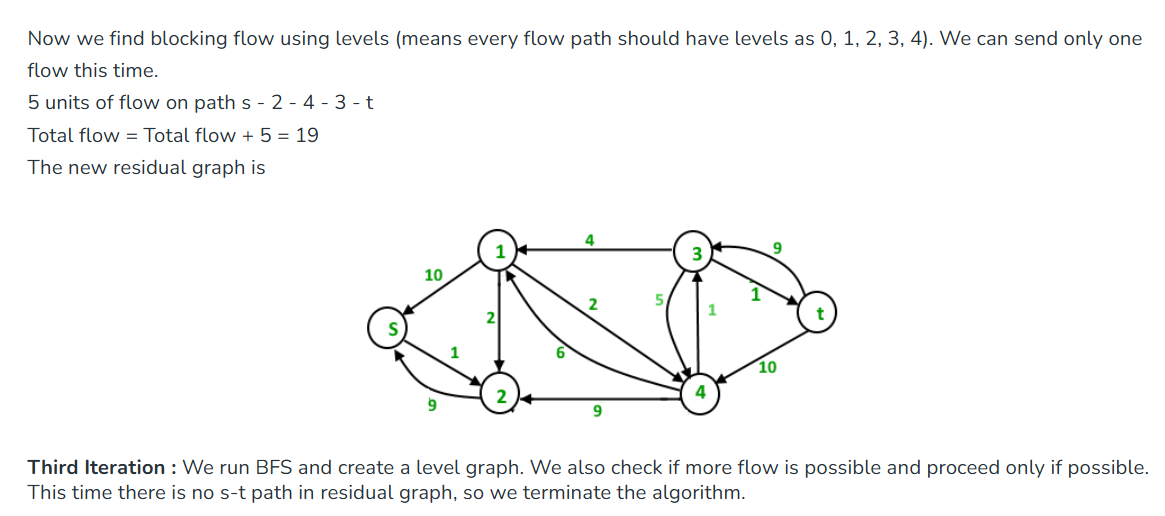

In [ ]:
# Python implementation of Dinic's Algorithm
class Edge:
    def __init__(self, v, flow, C, rev):
        self.v = v
        self.flow = flow
        self.C = C
        self.rev = rev

# Residual Graph


class Graph:
    def __init__(self, V):
        self.adj = [[] for i in range(V)]
        self.V = V
        self.level = [0 for i in range(V)]

    # add edge to the graph
    def addEdge(self, u, v, C):

        # Forward edge : 0 flow and C capacity
        a = Edge(v, 0, C, len(self.adj[v]))

        # Back edge : 0 flow and 0 capacity
        b = Edge(u, 0, 0, len(self.adj[u]))
        self.adj[u].append(a)
        self.adj[v].append(b)

    # Finds if more flow can be sent from s to t
    # Also assigns levels to nodes
    def BFS(self, s, t):
        for i in range(self.V):
            self.level[i] = -1

        # Level of source vertex
        self.level[s] = 0

        # Create a queue, enqueue source vertex
        # and mark source vertex as visited here
        # level[] array works as visited array also
        q = []
        q.append(s)
        while q:
            u = q.pop(0)
            for i in range(len(self.adj[u])):
                e = self.adj[u][i]
                if self.level[e.v] < 0 and e.flow < e.C:

                    # Level of current vertex is
                    # level of parent + 1
                    self.level[e.v] = self.level[u]+1
                    q.append(e.v)

        # If we can not reach to the sink we
        # return False else True
        return False if self.level[t] < 0 else True

# A DFS based function to send flow after BFS has
# figured out that there is a possible flow and
# constructed levels. This functions called multiple
# times for a single call of BFS.
# flow : Current flow send by parent function call
# start[] : To keep track of next edge to be explored
#           start[i] stores count of edges explored
#           from i
# u : Current vertex
# t : Sink
    def sendFlow(self, u, flow, t, start):
        # Sink reached
        if u == t:
            return flow

        # Traverse all adjacent edges one -by -one
        while start[u] < len(self.adj[u]):

            # Pick next edge from adjacency list of u
            e = self.adj[u][start[u]]
            if self.level[e.v] == self.level[u]+1 and e.flow < e.C:

                # find minimum flow from u to t
                curr_flow = min(flow, e.C-e.flow)
                temp_flow = self.sendFlow(e.v, curr_flow, t, start)

                # flow is greater than zero
                if temp_flow and temp_flow > 0:

                    # add flow to current edge
                    e.flow += temp_flow

                    # subtract flow from reverse edge
                    # of current edge
                    self.adj[e.v][e.rev].flow -= temp_flow
                    return temp_flow
            start[u] += 1

    # Returns maximum flow in graph
    def DinicMaxflow(self, s, t):

        # Corner case
        if s == t:
            return -1

        # Initialize result
        total = 0

        # Augument the flow while there is path
        # from source to sink
        while self.BFS(s, t) == True:

            # store how many edges are visited
            # from V { 0 to V }
            start = [0 for i in range(self.V+1)]
            while True:
                flow = self.sendFlow(s, float('inf'), t, start)
                if not flow:
                    break

                # Add path flow to overall flow
                total += flow

        # return maximum flow
        return total


g = Graph(6)
g.addEdge(0, 1, 10)
g.addEdge(0, 2, 10)
g.addEdge(1, 2, 2)
g.addEdge(1, 3, 4)
#g.addEdge(2, 1, 4)
g.addEdge(1, 4, 8)
g.addEdge(2, 4, 9)
g.addEdge(3, 5, 10)
g.addEdge(4, 3, 6)
g.addEdge(4, 5, 10)
print("Maximum flow", g.DinicMaxflow(0, 5))

# This code is contributed by rupasriachanta421.

Maximum flow 19


## 10. Алгоритм Хопкрофта-Карпа. Асимптотика работы.

Алгоритм Хопкрофта–Карпа — один из самых быстрых алгоритмов для поиска максимального паросочетания в двудольном графе.

**Идея задачи**:
Есть двудольный граф:

* вершины разбиты на две части: $𝐿$ и $𝑅$

* рёбра только между частями

Нужно выбрать максимальное количество рёбер так, чтобы:

никакие два выбранных ребра не имели общих вершин.

Это называется максимальное паросочетание.

До него использовали алгоритмы, которые добавляли по одному увеличивающему пути.
Хопкрофт–Карп ускорил процесс:

Он делает так:

* Сначала ищет все кратчайшие увеличивающие пути (через BFS).

* Затем одновременно увеличивает паросочетание по многим таким путям (через DFS).

То есть алгоритм работает пакетами путей, а не по одному.


**Шаги алгоритма**

1. Каждая итерация:

* BFS
* строим слоистую сеть (уровневый граф)
* находим длину кратчайших увеличивающих путей.

2. DFS

* ищем максимально возможное количество таких путей
* увеличиваем паросочетание.

3. Повторяем, пока пути существуют.



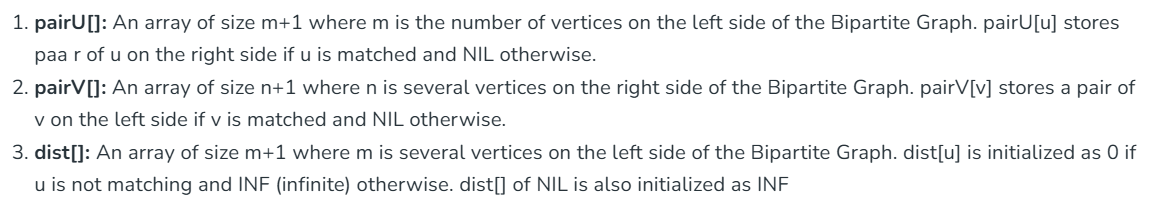

In [ ]:
# Python3 implementation of Hopcroft Karp algorithm for
# maximum matching
from queue import Queue

INF = 2147483647
NIL = 0

# A class to represent Bipartite graph for Hopcroft
# 3 Karp implementation
class BipGraph(object):
    # Constructor
    def __init__(self, m, n):
        # m and n are number of vertices on left
        # and right sides of Bipartite Graph
        self.__m = m
        self.__n = n
        # adj[u] stores adjacents of left side
        # vertex 'u'. The value of u ranges from 1 to m.
        # 0 is used for dummy vertex
        self.__adj = [[] for _ in range(m+1)]

    # To add edge from u to v and v to u
    def addEdge(self, u, v):
        self.__adj[u].append(v)  # Add u to v’s list.

    # Returns true if there is an augmenting path, else returns
    # false
    def bfs(self):
        Q = Queue()
        # First layer of vertices (set distance as 0)
        for u in range(1, self.__m+1):
            # If this is a free vertex, add it to queue
            if self.__pairU[u] == NIL:
                # u is not matched3
                self.__dist[u] = 0
                Q.put(u)
            # Else set distance as infinite so that this vertex
            # is considered next time
            else:
                self.__dist[u] = INF
        # Initialize distance to NIL as infinite
        self.__dist[NIL] = INF
        # Q is going to contain vertices of left side only.
        while not Q.empty():
            # Dequeue a vertex
            u = Q.get()
            # If this node is not NIL and can provide a shorter path to NIL
            if self.__dist[u] < self.__dist[NIL]:
                # Get all adjacent vertices of the dequeued vertex u
                for v in self.__adj[u]:
                    #  If pair of v is not considered so far
                    # (v, pairV[V]) is not yet explored edge.
                    if self.__dist[self.__pairV[v]] == INF:
                        # Consider the pair and add it to queue
                        self.__dist[self.__pairV[v]] = self.__dist[u] + 1
                        Q.put(self.__pairV[v])
        # If we could come back to NIL using alternating path of distinct
        # vertices then there is an augmenting path
        return self.__dist[NIL] != INF

    # Returns true if there is an augmenting path beginning with free vertex u
    def dfs(self, u):
        if u != NIL:
            # Get all adjacent vertices of the dequeued vertex u
            for v in self.__adj[u]:
                if self.__dist[self.__pairV[v]] == self.__dist[u] + 1:
                    # If dfs for pair of v also returns true
                    if self.dfs(self.__pairV[v]):
                        self.__pairV[v] = u
                        self.__pairU[u] = v
                        return True
            # If there is no augmenting path beginning with u.
            self.__dist[u] = INF
            return False
        return True

    def hopcroftKarp(self):
        # pairU[u] stores pair of u in matching where u
        # is a vertex on left side of Bipartite Graph.
        # If u doesn't have any pair, then pairU[u] is NIL
        self.__pairU = [0 for _ in range(self.__m+1)]

        # pairV[v] stores pair of v in matching. If v
        # doesn't have any pair, then pairU[v] is NIL
        self.__pairV = [0 for _ in range(self.__n+1)]

        # dist[u] stores distance of left side vertices
        # dist[u] is one more than dist[u'] if u is next
        # to u'in augmenting path
        self.__dist = [0 for _ in range(self.__m+1)]
        # Initialize result
        result = 0

        # Keep updating the result while there is an
        # augmenting path.
        while self.bfs():
            # Find a free vertex
            for u in range(1, self.__m+1):
                # If current vertex is free and there is
                # an augmenting path from current vertex
                if self.__pairU[u] == NIL and self.dfs(u):
                    result += 1
        return result


# Driver Program
if __name__ == "__main__":
    g = BipGraph(4, 4)
    g.addEdge(1, 2)
    g.addEdge(1, 3)
    g.addEdge(2, 1)
    g.addEdge(3, 2)
    g.addEdge(4, 2)
    g.addEdge(4, 4)
    print("Size of maximum matching is %d" % g.hopcroftKarp())

Size of maximum matching is 4


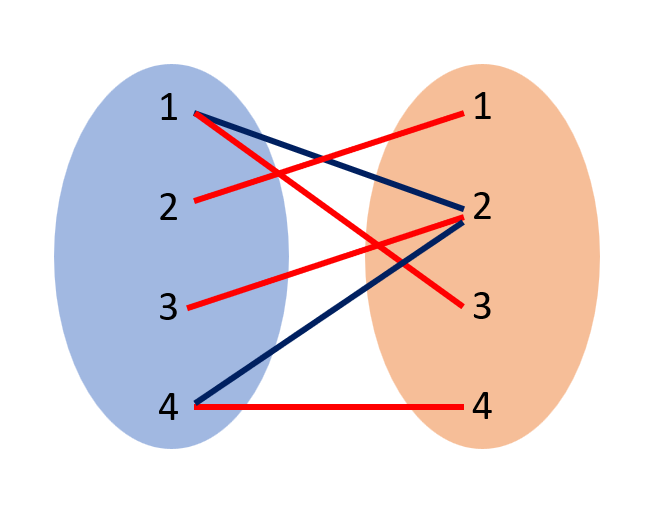

Красным отмечены рёбра, входящие в максимальное паросочетание.

### Сложность

Алгоритм работает за $𝑂(𝐸\sqrt{𝑉})$, $V$ — вершины, $𝐸$ — рёбра.



### Теорема Карзанова
Теорема Карзанова связана с тем, почему алгоритм Хопкрофта–Карпа работает так быстро.

После каждой фазы алгоритма длина кратчайшего увеличивающего пути строго увеличивается. Следствие - таких фаз может быть не больше примерно $\sqrt{𝑉}$.

А каждая фаза - $O(E)$ Отсюда итоговая сложность: $O(E\sqrt{V})$
Когда алгоритм за одну фазу использует все кратчайшие увеличивающие пути, он "уничтожает" возможность существования других путей такой же длины. Поэтому следующие пути будут длиннее, а длинных путей не может быть слишком много.


## 11. Бор, алгоритм Ахо-Корасик. Асимптотика работы.

**Префиксное дерево** или **бор** (англ. trie) — структура данных для компактного хранения строк, устроенная в виде дерева, где на рёбрах между вершинами записаны символы, а некоторые вершины помечены терминальными.

Говорят, что префиксное дерево принимает строку $s$, если существует такая терминальная вершина $v$, что, если выписать подряд все буквы на путях от корня до $v$, то получится строка $s$.

Бор сам по себе можно использовать для разных задач:

* Хранение строк: если есть много повторяющихся длинных префиксов, то бор может занимать гораздо меньше места, чем массив или set строк.
* Сортировка строк: по построенному бору можно пройтись dfs-ом и вывести все строки в лексикографическом порядке.
* Просто как множество строк: как мы увидим, в бор легко добавлять и удалять слова, а также делать проверки вхождения.

С точки зрения теории автоматов, каждая вершина — это состояние, а все корректные односимвольные дополнения являются корректными переходами в автомате. Бор таким образом является автоматом, проверяющим вхождение слова в множество.

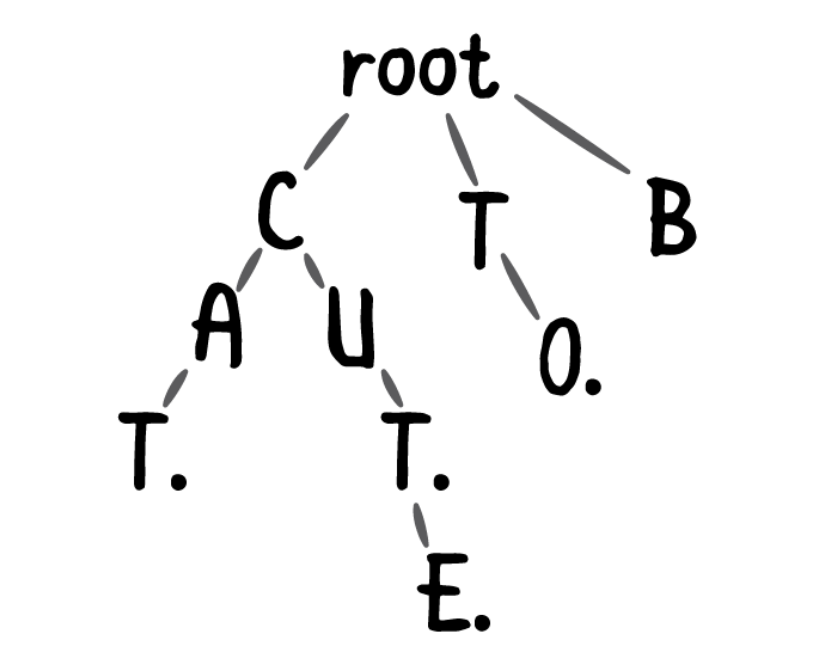

In [ ]:
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end = False


class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word: str) -> None:
        node = self.root
        for char in word:
            node = node.children.setdefault(char, TrieNode())
        node.is_end = True

    def search(self, word: str) -> bool:
        node = self._find_node(word)
        return node is not None and node.is_end

    def starts_with(self, prefix: str) -> bool:
        return self._find_node(prefix) is not None

    def delete(self, word: str) -> bool:
        """Удаляет слово. Возвращает True, если слово было удалено."""
        return self._delete(self.root, word, 0)

    def _delete(self, node, word, depth):
        if node is None:
            return False

        # дошли до конца слова
        if depth == len(word):
            if not node.is_end:
                return False  # слова не было
            node.is_end = False
            return len(node.children) == 0  # можно ли удалить узел

        char = word[depth]
        if char not in node.children:
            return False

        should_delete_child = self._delete(node.children[char], word, depth + 1)

        if should_delete_child:
            del node.children[char]
            return not node.is_end and len(node.children) == 0

        return False

    def words_with_prefix(self, prefix: str):
        """Возвращает все слова с данным префиксом."""
        node = self._find_node(prefix)
        if node is None:
            return []

        result = []
        self._dfs(node, prefix, result)
        return result

    def _dfs(self, node, path, result):
        if node.is_end:
            result.append(path)

        for char, next_node in node.children.items():
            self._dfs(next_node, path + char, result)

    def _find_node(self, prefix: str):
        node = self.root
        for char in prefix:
            if char not in node.children:
                return None
            node = node.children[char]
        return node


# Пример использования
trie = Trie()
words = ["cat", "car", "care", "dog", "door"]
for w in words:
    trie.insert(w)

print(trie.words_with_prefix("ca"))   # ['cat', 'car', 'care']

trie.delete("car")
print(trie.words_with_prefix("ca"))   # ['cat', 'care']

print(trie.search("car"))  # False
print(trie.search("care")) # True

['cat', 'car', 'care']
['cat', 'care']
False
True


# Алгоритм Ахо-Корасик
Представим, что мы работаем журналистами в некотором авторитарном государстве, контролирующем СМИ, и в котором время от времени издаются законы, запрещающие упоминать определенные политические события или использовать определенные слова. Как эффективно реализовать подобную цензуру программно?

Более формально, пусть дан набор строк $s_1,s_2,…,s_m$ алфавита размера $k$ суммарной длины $n$, называемый словарем, и длинный текст $t$. Необходимо определить, есть ли в тексте хотя бы одно слово из словаря, и если есть, то на какой позиции.

Мы уже умеем решать это, например, за $O(n⋅∣t∣)$ независимо проверяя каждое слово на вхождение, или за $O(max∣s_i ∣⋅∣t∣)$ хешируя все короткие подстроки. Но мы всё же хотим масштабируемое решение за $O(∣t∣)$, и сегодня мы построим автомат, который решит нашу задачу.

Алгоритм Ахо-Корасик (названный по фамилиям создателей, Альфреда Ахо и Маргарет Корасик; в народе — «карасик») за $O(nk)$ времени и памяти строит префиксное дерево для этого набора строк, а затем по этому дереву строит автомат, который может использоваться в этой и многих других строковых задачах. Алгоритм был открыт в 1975-м году, и с тех пор получил широкое распространение в системных программах для потоковой обработки текстов — например, в утилите grep.


Построим по словарю префиксное дерево (оно же бор). Предположим, что строки из словаря не являются подстроками друг друга — в этом случае большие можно выкинуть, но позже мы увидим, что это требование избыточно.

Для решения задачи мы построим автомат, в котором после считывания каждого очередного символа будет поддерживаться состояние, соответствующее наибольшей строке, являющейся одновременно

* префиксом какой-то строки из словаря, и
* суффиксом считанного на данный момент текста.

Этой информации о состоянии нам достаточно: если это состояние помечено терминальным, то суффикс совпадает с какой-то строкой из словаря, и мы выводим его. Иначе по определению мы нашли самый длинный принимаемый бором суффикс, но никакая его подстрока не является запрещенной, а значит в этой позиции никакое запрещенное слово не содержится.

Сложная часть — построить такой автомат, то есть по состоянию в префиксном дереве и новому символу быстро находить вершину, соответствующую наидлиннейшему входящему в бор суффиксу нового выписанного префикса текста. Для этого нам понадобятся несколько вспомогательных понятий.

1. Trie (префиксное дерево)

Хранит все шаблоны.

2. Fail links (суффиксные ссылки)

Позволяют быстро “откатываться”, если символ не подошёл.

**Определение**. Суффиксная ссылка $l(v)$ ведёт в вершину $u≠v$, которая соответствует наидлиннейшему принимаемому бором суффиксу $v$.

3. Output list

Хранит шаблоны, заканчивающиеся в узле.

### Часть 1: Построение Trie


In [ ]:
def _build_trie(self, patterns):
    for pattern in patterns:
        node = self.root
        for char in pattern:
            node = node.children.setdefault(char, Node())
        node.output.append(pattern)

Добавляем каждое слово в дерево посимвольно.

Для:
```python
["he", "she", "his"]
```
получим:
```python
root
 ├── h
 │   ├── e   ("he")
 │   └── i
 │       └── s ("his")
 └── s
     └── h
         └── e ("she")
```
output.append(pattern)

Когда слово заканчивается — отмечаем это:
```
node.output.append(pattern)
```
Например:
узел e в she хранит:
```
["she"]
```

### Часть 2: Fail Links
Что такое fail link?

Если не можем идти дальше по Trie —
прыгаем в максимально длинный возможный суффикс.
```python
def _build_fail_links(self):
Сначала:
for child in self.root.children.values():
    child.fail = self.root
```

Все дети корня ссылаются в root.

Потом BFS:
```python
while queue:
    current = queue.popleft()
```
Обходим дерево по уровням.
```python
Для каждого ребенка:
for char, child in current.children.items():
Ищем fail:
fail_node = current.fail

while fail_node and char not in fail_node.children:
    fail_node = fail_node.fail
```
Смысл:

Ищем ближайший узел,
где есть переход по тому же символу.

Пример:
```
Если стоим в:

she
```
и fail нужен для e,
ищем похожий путь через суффиксы.

Назначаем fail:
```python
child.fail = fail_node.children[char] if fail_node and char in fail_node.children else self.root
```


### Часть 3: Наследование output
Очень важная строка:
```python
child.output += child.fail.output
```
Почему?

Если нашли "hers",
можем одновременно найти "he".

Пример:
```
hers
```
может содержать окончания других шаблонов.



### Часть 4: Поиск по тексту
```python
def search(self, text):
#Начинаем с root:
node = self.root
#Идём по тексту:
for i, char in enumerate(text):
#Если перехода нет:
while node and char not in node.children:
    node = node.fail

#Прыгаем по fail links.

#Если переход есть:
node = node.children[char] if node and char in node.children else self.root
#Если нашли слово:
for pattern in node.output:
    results.append((i - len(pattern) + 1, pattern))
```
Пошаговый пример

Текст:
```
ushers
```
Читаем u

Нет перехода → root

Читаем s

Идем в s

Читаем h

Идем в sh

Читаем e

Идем в she

Нашли:
```
she
```
и через fail ещё:
```
he
```
Читаем r

Переход

Читаем s

Находим:
```
hers
```

In [ ]:
from collections import deque


class Node:
    def __init__(self):
        self.children = {}
        self.fail = None
        self.output = []  # список шаблонов, которые заканчиваются в этом узле


class AhoCorasick:
    def __init__(self, patterns):
        self.root = Node()
        self._build_trie(patterns)
        self._build_fail_links()

    def _build_trie(self, patterns):
        for pattern in patterns:
            node = self.root
            for char in pattern:
                node = node.children.setdefault(char, Node())
            node.output.append(pattern)

    def _build_fail_links(self):
        queue = deque()

        # 1. Для детей корня fail = root
        for child in self.root.children.values():
            child.fail = self.root
            queue.append(child)

        # 2. BFS
        while queue:
            current = queue.popleft()

            for char, child in current.children.items():
                fail_node = current.fail

                while fail_node and char not in fail_node.children:
                    fail_node = fail_node.fail

                child.fail = fail_node.children[char] if fail_node and char in fail_node.children else self.root
                child.output += child.fail.output

                queue.append(child)

    def search(self, text):
        node = self.root
        results = []

        for i, char in enumerate(text):
            while node and char not in node.children:
                node = node.fail

            node = node.children[char] if node and char in node.children else self.root

            for pattern in node.output:
                results.append((i - len(pattern) + 1, pattern))

        return results

In [ ]:
patterns = ["he", "she", "his", "hers"]
text = "ushers"

ac = AhoCorasick(patterns)
matches = ac.search("ushers")
print(matches)

[(1, 'she'), (2, 'he'), (2, 'hers')]


Пошаговая анимация построения Trie
```python
root
 ├── h
 │    ├── e [he]
 │    │    └── r
 │    │         └── s [hers]
 │    └── i
 │         └── s [his]
 └── s
      └── h
           └── e [she]
```
Строим fail-ссылки

Для узла sh

Путь:
```
s → h
```
```
fail(sh) = h
```
Почему?

Потому что:
если убрать s,
остаётся h,
а такой путь есть.

Для узла she
```
fail(she) = he
```
Получаем:
```python
root
 ├── h
 │    ├── e [he]
 │    │    └── r
 │    │         └── s [hers]
 │    └── i
 │         └── s [his]
 └── s
      └── h --fail--> h
           └── e [she] --fail--> e(he)
```
Пошаговый поиск в "ushers"

```python
u s h e r s
0 1 2 3 4 5
```
Символ u

Нет перехода → root

Символ s

Идём в s

Символ h

Идём в sh

Символ e

Идём в she

Найдено:
```
she
```
Через fail:
```
she → fail → he
```
Находим ещё:
```
he
```
Символ r

Переходим дальше

Символ s

Находим:
```
hers
```
Финальный результат:
```python
[(1, 'she'), (2, 'he'), (2, 'hers')]
```

**Сложность**  
Построение:
$O(sum(len(patterns)))$  
Поиск:
$O(len(text) + matches)$

## 12. Быстрое преобразование Фурье. Использование для решения задачи о количестве вхождений с ошибками. Асимптотика работы.

Здесь мы рассмотрим алгоритм, который позволяет перемножить два полинома длиной $n$ за время $O(n \log n)$, что значительно лучше времени $O(n^2)$, достигаемого тривиальным алгоритмом умножения. Очевидно, что умножение двух длинных чисел можно свести к умножению полиномов, поэтому два длинных числа также можно перемножить за время $O(n \log n)$.

Изобретение Быстрого преобразования Фурье приписывается Кули (Coolet) и Таки (Tukey) — 1965 г. На самом деле БПФ неоднократно изобреталось до этого, но важность его в полной мере не осознавалась до появления современных компьютеров. Некоторые исследователи приписывают открытие БПФ Рунге (Runge) и Кёнигу (Konig) в 1924 г. Наконец, открытие этого метода приписывается ещё Гауссу (Gauss) в 1805 г.



### Дискретное преобразование Фурье (ДПФ)
Пусть имеется многочлен n-ой степени:
$A(x) = a_0 x^0 + a_1 x^1 + \ldots + a_{n-1} x^{n-1}$

Не теряя общности, можно считать, что $n$ является степенью 2. Если в действительности $n$ не является степенью 2, то мы просто добавим недостающие коэффициенты, положив их равными нулю.

Из теории функций комплексного переменного известно, что комплексных корней n-ой степени из единицы существует ровно n. Обозначим эти корни через $w_{n,k}, k = 0 \ldots {n-1}$, тогда известно, что $w_{n,k} = e^{ i \frac{ 2 \pi k }{ n } }$. Кроме того, один из этих корней $w_n = w_{n,1} = e^{ i \frac{ 2 \pi }{ n } }$ (называемый главным значением корня n-ой степени из единицы) таков, что все остальные корни являются его степенями: $w_{n,k} = (w_n)^k$.

Тогда дискретным преобразованием Фурье (ДПФ) (discrete Fourier transform, DFT) многочлена $A(x)$ (или, что то же самое, ДПФ вектора его коэффициентов $(a_0, a_1, \dots, a_{n-1}))$ называются значения этого многочлена в точках $x = w_{n,k}$, т.е. это вектор:

 ${\rm DFT}(a_0, a_1, \ldots, a_{n-1}) = (y_0, y_1,[...]
 = (A(w_n^0), A(w_n^1), \ldots, A(w_n^{n-1}))$.

Аналогично определяется и обратное дискретное преобразование Фурье $(InverseDFT)$. Обратное ДПФ для вектора значений многочлена $(y_0, y_1, \ldots y_{n-1})$ — это вектор коэффициентов многочлена $(a_0, a_1, \ldots, a_{n-1})$:

 ${\rm InverseDFT}(y_0, y_1, \ldots, y_{n-1}) = (a_0, a_1, \ldots, a_{n-1})$

Таким образом, если прямое ДПФ переходит от коэффициентов многочлена к его значениям в комплексных корнях n-ой степени из единицы, то обратное ДПФ — наоборот, по значениям многочлена восстанавливает коэффициенты многочлена.

### Быстрое преобразование Фурье
Быстрое преобразование Фурье (fast Fourier transform) — это метод, позволяющий вычислять ДПФ за время $O(n \log n)$. Этот метод основывается на свойствах комплексных корней из единицы (а именно, на том, что степени одних корней дают другие корни).

Основная идея БПФ заключается в разделении вектора коэффициентов на два вектора, рекурсивном вычислении ДПФ для них, и объединении результатов в одно БПФ.

Итак, пусть имеется многочлен $A(x)$ степени $n$, где $n$ — степень двойки, и $n>1$:

 $A(x) = a_0 x^0 + a_1 x^1 + \ldots + a_{n-1} x^{n-1}$

Разделим его на два многочлена, один — с чётными, а другой — с нечётными коэффициентами:

 $A_0(x) = a_0 x^0 + a_2 x^1 + \ldots + a_{n-2} x^{\frac{n}{2} - 1}$  
 $A_1(x) = a_1 x^0 + a_3 x^1 + \ldots + a_{n-1} x^{\frac{n}{2} - 1}$

Нетрудно убедиться, что:

 $A(x) = A_0(x^2) + x A_1(x^2). ~~~~~~~(1)$

Многочлены $A_0$ и $A_1$ имеют вдвое меньшую степень, чем многочлен $A$. Если мы сможем за линейное время по вычисленным ${\rm DFT}(A_0)$ и ${\rm DFT}(A_1)$ вычислить ${\rm DFT}(A)$, то мы и получим искомый алгоритм быстрого преобразования Фурье (т.к. это стандартная схема алгоритма "разделяй и властвуй", и для неё известна асимптотическая оценка $O(n \log n)$).

Итак, пусть мы имеем вычисленные вектора $\{ y_k^0 \}_{k=0}^{n/2-1} = {\rm DFT}(A_0)$ и $\{ y_k^1 \}_{k=0}^{n/2-1} = {\rm DFT}(A_1)$. Найдём выражения для $\{ y_k \}_{k=0}^{n-1} = {\rm DFT}(A)$.

Во-первых, вспоминая $(1)$, мы сразу получаем значения для первой половины коэффициентов:

 $y_k = y_k^0 + w_n^k y_k^1, ~~~~k = 0 \ldots n/2-1$

Для второй половины коэффициентов после преобразований также получаем простую формулу:

 $y_{k+n/2} = A(w_n^{k+n/2}) = A_0(w_n^{2k+n}) + w_{n}^{k+n/2} A_1(w_n^{2k+n}) = A_0(w_n^{2k}w_n^{n}) - w_n^k w_n^{n/2}A_1(w_n^{2k}w_n^{n}) = A_0(w_n^{2k}) - w_n^{k}A_1(w_n^{2k}) = y_k^0 - w_{n}^{k}y_k^1$

(Здесь мы воспользовались $(1)$, а также тождествами $w_n^n = 1, w_n^{n/2} = -1$.)

Итак, в результате мы получили формулы для вычисления всего вектора $\{ y_k \}$:

 $y_k = y_k^0 + w_n^k y_k^1, \ \ \ \ k = 0 \ldots n/2-1$
 $y_{k+n/2} = y_k^0 - w_n^k y_k^1, \ \ \ \ k = 0 \ldots n/2-1$

(эти формулы, т.е. две формулы вида $a+bc$ и $a-bc$, иногда называют "преобразование бабочки" ("butterfly operation"))

Тем самым, мы окончательно построили алгоритм БПФ.

### Обратное БПФ
Итак, пусть дан вектор $(y_0, y_1, \ldots, y_{n-1})$ — значения многочлена $A$ степени $n$ в точках $x = w_n^k$. Требуется восстановить коэффициенты $(a_0, a_1, \ldots, a_{n-1})$ многочлена. Эта известная задача называется интерполяцией, для этой задачи есть и общие алгоритмы решения, однако в данном случае будет получен очень простой алгоритм (простой тем, что он практически не отличается от прямого БПФ).

ДПФ мы можем записать, согласно его определению, в матричном виде:

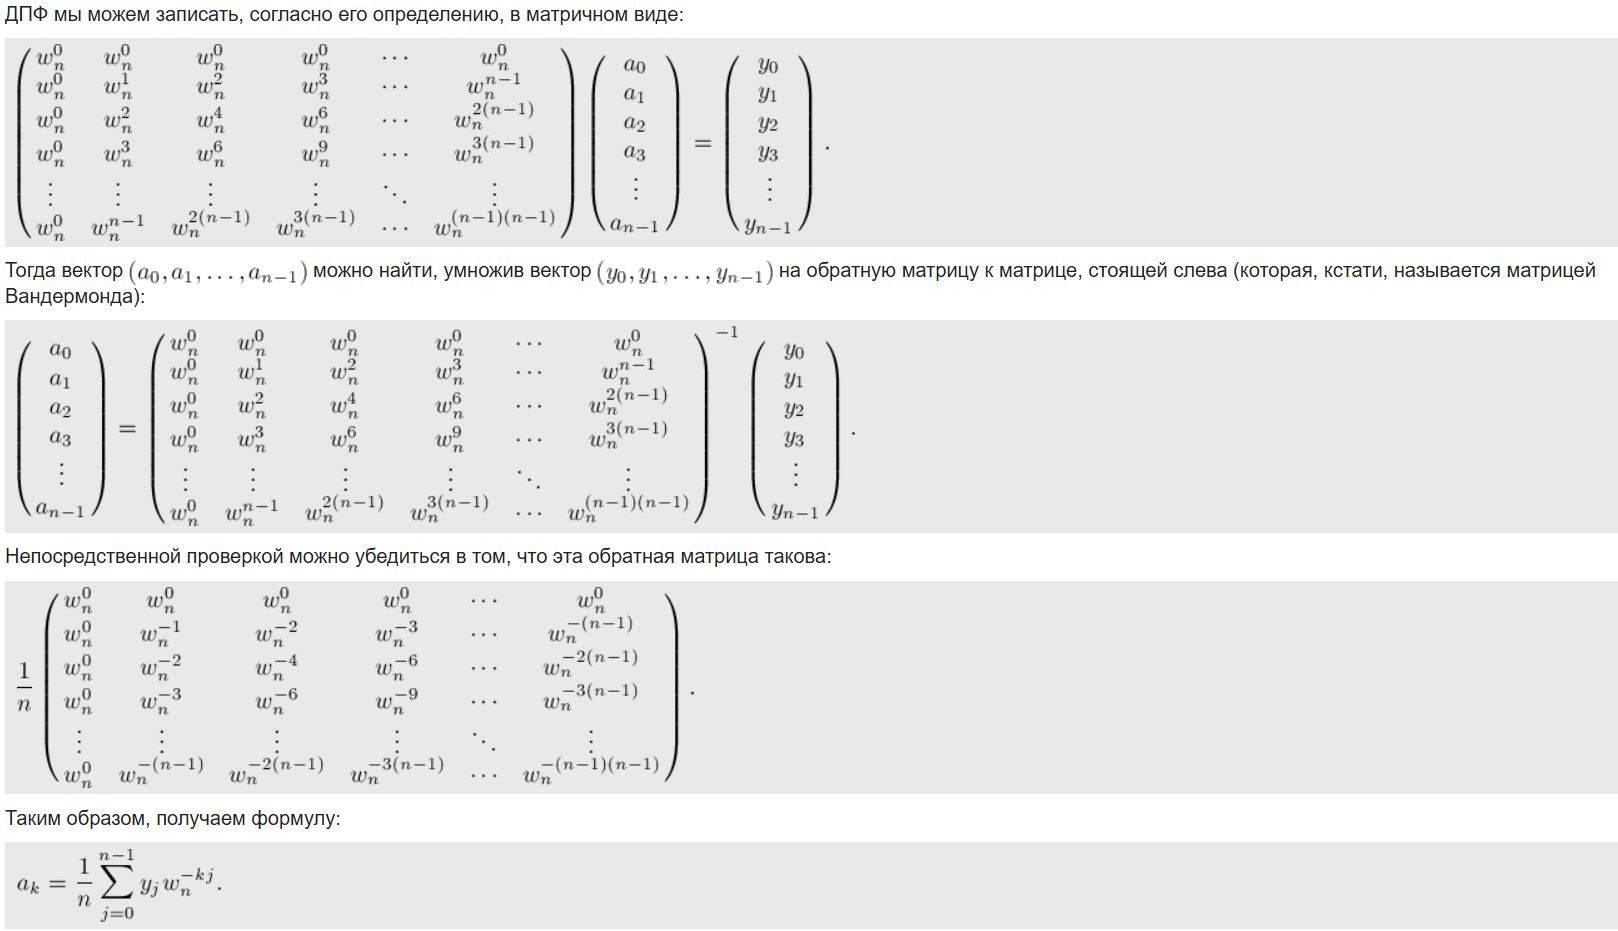

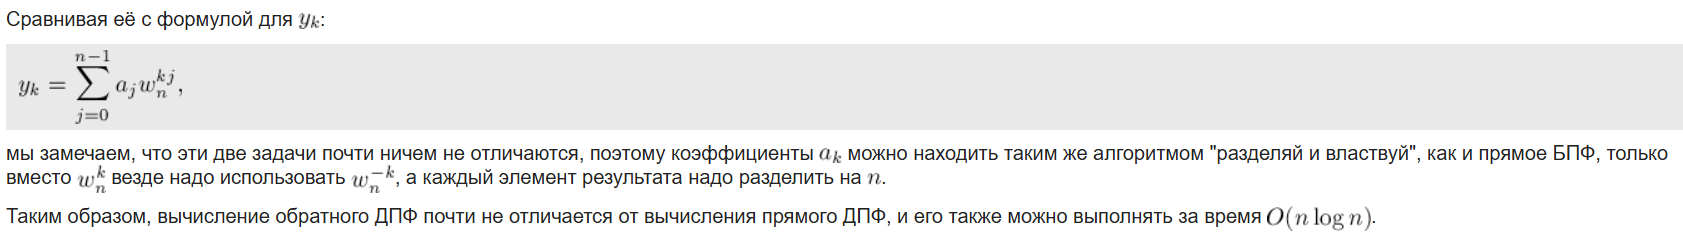

In [ ]:
import math
import cmath

def fft_recursive_fixed(x, inverse=False):
    """
    Рекурсивная реализация БПФ.
    Правильная рекурсия с битовой инверсией.
    """
    n = len(x)

    if n == 1:
        return x

    if n & (n - 1) != 0:
        raise ValueError("Длина массива должна быть степенью двойки")

    # Правильное разделение: четные и нечетные индексы
    even = fft_recursive_fixed(x[0::2], inverse)
    odd = fft_recursive_fixed(x[1::2], inverse)

    result = [0] * n

    # Поворачивающие множители
    for k in range(n // 2):
        # Прямое БПФ: exp(-2πi * k / n)
        # Обратное БПФ: exp(2πi * k / n)
        if inverse:
            angle = 2 * math.pi * k / n
        else:
            angle = -2 * math.pi * k / n

        # Комплексная экспонента: cos(angle) + i*sin(angle)
        w = complex(math.cos(angle), math.sin(angle))

        # Операция "бабочка"
        result[k] = even[k] + w * odd[k]
        result[k + n // 2] = even[k] - w * odd[k]

    # Для обратного БПФ делим на n
    if inverse:
        result = [x / n for x in result]

    return result


def bit_reverse_copy(x):
    """
    Перестановка элементов в порядке битовой инверсии.
    Это необходимо для итеративной реализации, но для рекурсивной
    порядок должен быть правильным из-за способа разделения.
    """
    n = len(x)
    # Находим количество бит
    bits = n.bit_length() - 1

    result = [0] * n
    for i in range(n):
        # Битовый реверс
        rev = 0
        for j in range(bits):
            if i & (1 << j):
                rev |= 1 << (bits - 1 - j)
        result[rev] = x[i]

    return result


def fft_iterative(x, inverse=False):
    """
    ИТЕРАТИВНАЯ реализация БПФ.
    Использует битовую инверсию и итеративную бабочку.
    """
    n = len(x)

    if n & (n - 1) != 0:
        raise ValueError("Длина массива должна быть степенью двойки")

    # Биговая инверсия
    # Находим количество бит
    bits = n.bit_length() - 1

    # Создаем массив с битовой инверсией
    result = [0] * n
    for i in range(n):
        # Вычисляем битовый реверс
        rev = 0
        for j in range(bits):
            if i & (1 << j):
                rev |= 1 << (bits - 1 - j)
        result[rev] = x[i]

    # Итеративное БПФ
    length = 2
    while length <= n:
        # Поворачивающий множитель для текущей длины
        if inverse:
            angle = 2 * math.pi / length
        else:
            angle = -2 * math.pi / length

        wlen = complex(math.cos(angle), math.sin(angle))

        for i in range(0, n, length):
            w = 1 + 0j
            for j in range(i, i + length // 2):
                u = result[j]
                v = result[j + length // 2] * w

                result[j] = u + v
                result[j + length // 2] = u - v

                w *= wlen

        length <<= 1

    # Для обратного БПФ делим на n
    if inverse:
        result = [x / n for x in result]

    return result


def multiply_polynomials_fft(poly1, poly2):
    """
    Умножение многочленов через БПФ (итеративная версия).
    """
    result_size = len(poly1) + len(poly2) - 1

    # Находим ближайшую степень двойки
    n = 1
    while n < result_size:
        n <<= 1

    # Создаем комплексные массивы
    a = [complex(poly1[i] if i < len(poly1) else 0, 0) for i in range(n)]
    b = [complex(poly2[i] if i < len(poly2) else 0, 0) for i in range(n)]

    # Прямое БПФ
    A = fft_iterative(a, inverse=False)
    B = fft_iterative(b, inverse=False)

    # Поэлементное умножение
    C = [A[i] * B[i] for i in range(n)]

    # Обратное БПФ
    result_complex = fft_iterative(C, inverse=True)

    # Округление
    result = []
    for i in range(result_size):
        val = result_complex[i].real
        # Округляем до ближайшего целого
        rounded = int(round(val))
        # Дополнительная проверка из-за погрешностей
        if abs(val - rounded) > 0.1:
            # Если значение далеко от целого, возможно, это ошибка
            print(f"Предупреждение: result[{i}] = {val} далеко от целого")
        result.append(rounded)

    return result


def test_fft_implementation():
    """Тестирование различных реализаций БПФ."""

    print("=" * 70)
    print("ТЕСТИРОВАНИЕ ИТЕРАТИВНОЙ ВЕРСИИ БПФ")
    print("=" * 70)

    # Тест 1: Базовый тест с импульсом
    print("\n1. Тест с импульсным сигналом:")
    test_signal = [1.0, 0.0, 0.0, 0.0]
    print(f"   Вход: {test_signal}")

    fft_result = fft_iterative(test_signal, inverse=False)
    print(f"   БПФ: {[f'{x.real:.2f}{x.imag:+.2f}j' for x in fft_result]}")

    ifft_result = fft_iterative(fft_result, inverse=True)
    print(f"   Обратное БПФ: {[f'{x.real:.2f}' for x in ifft_result]}")

    # Проверка восстановления
    success = all(abs(ifft_result[i].real - test_signal[i]) < 1e-6
                  for i in range(len(test_signal)))
    print(f"   Восстановление: {'✓' if success else '✗'}")

    # Тест 2: Умножение многочленов
    print("\n2. Умножение многочленов [1,2,3] * [4,5]:")

    poly1 = [1, 2, 3]
    poly2 = [4, 5]

    result = multiply_polynomials_fft(poly1, poly2)
    print(f"   Результат: {result}")

    expected = [4, 13, 22, 15]
    print(f"   Ожидалось: {expected}")

    if result == expected:
        print("   ✓ УСПЕХ!")
    else:
        print("   ✗ ОШИБКА!")

    # Тест 3: Все тестовые случаи
    print("\n3. Полное тестирование:")

    test_cases = [
        ([1, 2, 3], [4, 5], [4, 13, 22, 15]),
        ([1, 1], [1, -1], [1, 0, -1]),
        ([1, 2], [3, 4], [3, 10, 8]),
        ([1, 0, 1], [1, 0, 1], [1, 0, 2, 0, 1]),
        ([1, 1, 1, 1], [1, 1], [1, 2, 2, 2, 1]),
        ([5], [1, 2, 3], [5, 10, 15]),
    ]

    all_passed = True
    for i, (p1, p2, expected) in enumerate(test_cases, 1):
        result = multiply_polynomials_fft(p1, p2)

        # Наивное умножение для двойной проверки
        naive = [0] * (len(p1) + len(p2) - 1)
        for j in range(len(p1)):
            for k in range(len(p2)):
                naive[j + k] += p1[j] * p2[k]

        if result == expected and result == naive:
            print(f"   ✓ Тест {i}: {p1} * {p2} = {result}")
        else:
            print(f"   ✗ Тест {i}: {p1} * {p2}")
            print(f"       БПФ: {result}")
            print(f"       Ожидалось: {expected}")
            print(f"       Наивно: {naive}")
            all_passed = False

    if all_passed:
        print("\n🎉 ВСЕ ТЕСТЫ ПРОЙДЕНЫ! 🎉")
    else:
        print("\n⚠️ Некоторые тесты не пройдены")


def manual_fft_4_working(x):
    """
    Рабочая реализация БПФ для N=4 для проверки.
    """
    # БПФ для N=2
    def fft_2(x):
        return [x[0] + x[1], x[0] - x[1]]

    # Разделяем на четные и нечетные
    even = [x[0], x[2]]
    odd = [x[1], x[3]]

    # Вычисляем БПФ для половин
    E = fft_2(even)
    O = fft_2(odd)

    # Объединяем
    result = [0, 0, 0, 0]
    # Корни для N=4
    w0 = 1 + 0j
    w1 = -1j  # exp(-πi/2)
    w2 = -1 + 0j  # exp(-πi)
    w3 = 1j  # exp(-3πi/2)

    result[0] = E[0] + w0 * O[0]
    result[1] = E[1] + w1 * O[0]
    result[2] = E[0] + w2 * O[1]
    result[3] = E[1] + w3 * O[1]

    return result


def compare_implementations():
    """Сравнение разных реализаций БПФ."""

    print("\n" + "=" * 70)
    print("СРАВНЕНИЕ РЕАЛИЗАЦИЙ")
    print("=" * 70)

    test_signal = [1.0, 2.0, 3.0, 4.0]

    print(f"\nТестовый сигнал: {test_signal}")

    # Наша итеративная реализация
    fft_iter = fft_iterative(test_signal, inverse=False)
    print(f"\nИтеративная БПФ: {[f'{x.real:.2f}{x.imag:+.2f}j' for x in fft_iter]}")

    # Ручная реализация для N=4
    fft_manual = manual_fft_4_working(test_signal)
    print(f"Ручная БПФ (N=4): {[f'{x.real:.2f}{x.imag:+.2f}j' for x in fft_manual]}")

    # NumPy для проверки
    import numpy as np
    fft_numpy = np.fft.fft(test_signal)
    print(f"NumPy БПФ:       {[f'{x.real:.2f}{x.imag:+.2f}j' for x in fft_numpy]}")

    # Проверка итеративной реализации с NumPy
    diff = max(abs(fft_iter[i] - fft_numpy[i]) for i in range(len(test_signal)))
    print(f"\nМаксимальная разница с NumPy: {diff:.2e}")

    if diff < 1e-6:
        print("✓ Итеративная реализация работает корректно!")
    else:
        print("✗ Итеративная реализация имеет ошибки")


if __name__ == "__main__":
    # Запускаем тесты
    test_fft_implementation()
    compare_implementations()

    # Дополнительный тест с пошаговой демонстрацией
    print("\n" + "=" * 70)
    print("ДЕМОНСТРАЦИЯ УМНОЖЕНИЯ МНОГОЧЛЕНОВ")
    print("=" * 70)

    poly1 = [1, 2, 3]
    poly2 = [4, 5]

    print(f"\nМногочлен A: {poly1}")
    print(f"Многочлен B: {poly2}")

    result = multiply_polynomials_fft(poly1, poly2)

    # Форматируем вывод
    def polynomial_to_string(coeffs):
        terms = []
        for i, coeff in enumerate(coeffs):
            if coeff != 0:
                if i == 0:
                    terms.append(f"{coeff}")
                elif i == 1:
                    terms.append(f"{coeff}x")
                else:
                    terms.append(f"{coeff}x^{i}")
        return " + ".join(terms) if terms else "0"

    print(f"\n({polynomial_to_string(poly1)}) * ({polynomial_to_string(poly2)})")
    print(f"= {polynomial_to_string(result)}")

    # Проверка
    expected = [4, 13, 22, 15]
    if result == expected:
        print("\n✓ Результат правильный!")
    else:
        print(f"\n✗ Ошибка! Результат: {result}, ожидалось: {expected}")

ТЕСТИРОВАНИЕ ИТЕРАТИВНОЙ ВЕРСИИ БПФ

1. Тест с импульсным сигналом:
   Вход: [1.0, 0.0, 0.0, 0.0]
   БПФ: ['1.00+0.00j', '1.00+0.00j', '1.00+0.00j', '1.00+0.00j']
   Обратное БПФ: ['1.00', '0.00', '0.00', '0.00']
   Восстановление: ✓

2. Умножение многочленов [1,2,3] * [4,5]:
   Результат: [4, 13, 22, 15]
   Ожидалось: [4, 13, 22, 15]
   ✓ УСПЕХ!

3. Полное тестирование:
   ✓ Тест 1: [1, 2, 3] * [4, 5] = [4, 13, 22, 15]
   ✓ Тест 2: [1, 1] * [1, -1] = [1, 0, -1]
   ✓ Тест 3: [1, 2] * [3, 4] = [3, 10, 8]
   ✓ Тест 4: [1, 0, 1] * [1, 0, 1] = [1, 0, 2, 0, 1]
   ✓ Тест 5: [1, 1, 1, 1] * [1, 1] = [1, 2, 2, 2, 1]
   ✓ Тест 6: [5] * [1, 2, 3] = [5, 10, 15]

🎉 ВСЕ ТЕСТЫ ПРОЙДЕНЫ! 🎉

СРАВНЕНИЕ РЕАЛИЗАЦИЙ

Тестовый сигнал: [1.0, 2.0, 3.0, 4.0]

Итеративная БПФ: ['10.00+0.00j', '-2.00+2.00j', '-2.00+0.00j', '-2.00-2.00j']
Ручная БПФ (N=4): ['10.00+0.00j', '-2.00-6.00j', '6.00+0.00j', '-2.00-2.00j']
NumPy БПФ:       ['10.00+0.00j', '-2.00+2.00j', '-2.00+0.00j', '-2.00-2.00j']

Максимальная разница

### Применение №2: поиск вхождений с ошибками
Дано:

* текст $T$ длины $n$
* шаблон $P$ длины $m$

Нужно найти позиции, где шаблон совпадает с ≤ k ошибками.

Давайте преобразуем строки в числовые массивы и используем свёртку.

Для точного совпадения:
* кодируем символы
* считаем совпадения через свёртку: $c[k]=∑a[i]⋅b[k−i]$, где a и b - массивы.

Для совпадений с ошибками используется трюк:

1. Для каждого символа алфавита:
создаём бинарные массивы:
* $A_c[i]=1, если T[i]=c$
* $B_c[i]=1, если P[i]=c$
2. Разворачиваем шаблон
3. Для каждого символа:
* считаем свёртку:
* получаем количество совпадений по этому символу
4. Складываем результаты
получаем число совпадений в каждой позиции

$ошибки=m−matches$

FFT позволяет «сравнить» шаблон со всеми позициями текста одновременно.

### Асимптотика

Пусть:

n — длина текста  
m — длина шаблона  
σ — размер алфавита  
Время: $O(nlogn) => O(σ · n log n)$

Если алфавит фиксирован (например, ASCII): $O(n log n)$  
Память: $O(n)$
